# Модель прогнозирования стоимости жилья для агенства недвижимости

# Housing price forecasting model for a real estate agency

**Введение:**

В рамках проекта рассматривается задача анализа и прогнозирования стоимости жилой недвижимости на основе данных о продажах объектов в США.

**Бизнес задачи:** Разработать инструмент, позволяющий агентству недвижимости более точно и быстро оценивать рыночную стоимость объектов, что способствует:

- сокращению времени сделки
- снижению риска недооценки или переоценки недвижимости
- повышению конкурентоспособности агентства.

**Техническая задача для специалиста в Data Science:** Разработать и внедрить модель машинного обучения для прогнозирования стоимости недвижимости на основе доступных характеристик объекта.

**Критерии успеха модели:**

Качество модели будет оцениваться с использованием метрик регрессии:

- MAE (средняя абсолютная ошибка)
- RMSE (среднеквадратичная ошибка)

Модель должна обеспечивать приемлемую точность прогнозирования, достаточную для практического применения в бизнесе.

**Основные этапы проекта:**

1. Очистка и предобработка данных:

 - обработка пропусков
 - устранение дубликатов
 - унификация категориальных признаков (устранение синонимов и сокращений)

2. Разведывательный анализ данных (EDA):

 - анализ структуры данных
 - выявление аномалий и выбросов
 - исследование распределений признаков
   
3. Feature engineering:
   
 - создание новых признаков
 - преобразование категориальных переменных
 - масштабирование признаков (при необходимости)

4. Анализ факторов, влияющих на стоимость недвижимости:
   
 - корреляционный анализ
 - оценка важности признаков

5. Построение и обучение моделей:

 - базовая модель (baseline)
 - подбор и обучение более сложных моделей

6. Оценка качества моделей и выбор финальной:

 - сравнение по метрикам
 - анализ ошибок

7. Разработка прототипа веб-сервиса:

 - реализация API для получения предсказаний
 - демонстрация работы модели


**Introduction:**

This project examines the problem of analyzing and forecasting residential real estate prices based on sales data in the United States.

**Business Objectives:** Develop a tool that allows a real estate agency to more accurately and quickly estimate the market value of properties, which will:

- Reduce transaction times
- Reduce the risk of undervaluing or overvaluing properties
- Increase the agency's competitiveness.

**Technical Task for a Data Science Specialist:** Develop and implement a machine learning model for predicting real estate prices based on available property characteristics.

**Model Success Criteria:**

Model quality will be assessed using regression metrics:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Square Error)

The model must provide acceptable forecasting accuracy sufficient for practical business use.

**Main Project Stages:**

1. Data cleaning and preprocessing:

- Handling gaps
- Removing duplicates
- Unifying categorical features (removing synonyms and abbreviations)

2. Conducting Exploratory Data Analysis (EDA):

- Data structure analysis
- Anomaly and outlier detection
- Feature distribution analysis

3. Feature engineering:

- Creating new features
- Transforming categorical variables
- Feature scaling (if necessary)

4. Analyzing factors affecting real estate value:

- Correlation analysis
- Evaluating feature importance

5. Building and training models:

- Baseline model
- Selecting and training more complex models

6. Assessing model quality and selecting the final model:

- Comparison by metrics
- Error analysis

7. Developing a web service prototype:

- Implementing an API for retrieving predictions
- Demonstrating the model's operation

### Данные и их описание
### Data and its description

 - **'status'** — статус продажи
   
 - **'private pool'** и **'PrivatePool'** — наличие собственного бассейна

 - **'propertyType'** — тип объекта недвижимости

 - **'street'** — адрес объекта

 - **'baths'** — количество ванных комнат

 - **'homeFacts'** — сведения о строительстве объекта (содержит несколько  типов сведений, влияющих на оценку объекта)

 - **'fireplace'** — наличие камина

 - **'city'** — город

 - **'schools'** — сведения о школах в районе

 - **'sqft'** — площадь в футах

 - **'zipcode'** — почтовый индекс

 - **'beds'** — количество спален

 - **'state'** — штат

 - **'stories'** — количество этажей

 - **'mls-id'** и **'MlsId'** — идентификатор MLS (Multiple Listing Service, система  мультилистинга)

 - **'target'** — цена объекта недвижимости (целевой признак, который необходимо спрогнозировать)

- **'status'** — sale status

- **'private pool'** and **'PrivatePool'** — presence of a private pool

- **'propertyType'** — property type

- **'street'** — property address

- **'baths'** — number of bathrooms

- **'homeFacts'** — property construction information (contains several types of information that affect the property's valuation)

- **'fireplace'** — presence of a fireplace

- **'city'** — city

- **'schools'** — information about schools in the area

- **'sqft'** — square footage

- **'zipcode'** — zip code

- **'beds'** — number of bedrooms

- **'state'** — state

- **'stories'** — number of floors

- **'mls-id'** and **'MlsId'** — MLS (Multiple Listing Service) identifier

- **'target'** — property price (the target attribute to be predicted)

### 1. Очистка и предобработка данных
### 1. Data cleaning and preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import category_encoders as ce
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn import metrics
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [119]:
# Прочитаем наши данные
# Let's read our data
data = pd.read_csv("data_property.csv")
print('Data shape: {}'.format(data.shape))
data.head(5)

Data shape: (377185, 18)


,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target
0,Active,NaN,Single Family Home,240 Heather Ln,3.5,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",Gas Logs,Southern Pines,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'N...",2900,28387,4,NC,NaN,NaN,NaN,611019,"$418,000"
1,for sale,NaN,single-family home,12911 E Heroy Ave,3 Baths,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",NaN,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...","1,947 sqft",99216,3 Beds,WA,2.0,NaN,NaN,201916904,"$310,000"
2,for sale,NaN,single-family home,2005 Westridge Rd,2 Baths,"{'atAGlanceFacts': [{'factValue': '1961', 'fac...",yes,Los Angeles,"[{'rating': ['8/10', '4/10', '8/10'], 'data': ...","3,000 sqft",90049,3 Beds,CA,1.0,NaN,yes,FR19221027,"$2,895,000"
3,for sale,NaN,single-family home,4311 Livingston Ave,8 Baths,"{'atAGlanceFacts': [{'factValue': '2006', 'fac...",yes,Dallas,"[{'rating': ['9/10', '9/10', '10/10', '9/10'],...","6,457 sqft",75205,5 Beds,TX,3.0,NaN,NaN,14191809,"$2,395,000"
4,for sale,NaN,lot/land,1524 Kiscoe St,NaN,"{'atAGlanceFacts': [{'factValue': '', 'factLab...",NaN,Palm Bay,"[{'rating': ['4/10', '5/10', '5/10'], 'data': ...",NaN,32908,NaN,FL,NaN,NaN,NaN,861745,"$5,000"


In [120]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377185 entries, 0 to 377184
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   status        337267 non-null  object
 1   private pool  4181 non-null    object
 2   propertyType  342452 non-null  object
 3   street        377183 non-null  object
 4   baths         270847 non-null  object
 5   homeFacts     377185 non-null  object
 6   fireplace     103114 non-null  object
 7   city          377151 non-null  object
 8   schools       377185 non-null  object
 9   sqft          336608 non-null  object
 10  zipcode       377185 non-null  object
 11  beds          285903 non-null  object
 12  state         377185 non-null  object
 13  stories       226469 non-null  object
 14  mls-id        24942 non-null   object
 15  PrivatePool   40311 non-null   object
 16  MlsId         310305 non-null  object
 17  target        374704 non-null  object
dtypes: object(18)
memory usa

In [121]:
# Смотрим количество пропусков
# We look at the number of absences
data.isnull().sum()

status           39918
private pool    373004
propertyType     34733
street               2
baths           106338
homeFacts            0
fireplace       274071
city                34
schools              0
sqft             40577
zipcode              0
beds             91282
state                0
stories         150716
mls-id          352243
PrivatePool     336874
MlsId            66880
target            2481
dtype: int64

Как видим пропусков довольно много, будем работать с каждым признаком отдельно.

As we can see, there are quite a lot of gaps; we will work with each feature separately.

In [122]:
# Проверяем данные на наличие дубликатов
# Checking data for duplicates
data.duplicated().sum()

50

In [123]:
# Удаляем дубликаты
# Remove duplicates
data = data.drop_duplicates()
data.shape

(377135, 18)

In [124]:
data.describe()

,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target
count,337218,4181,342402,377133,270827,377135,103111,377101,377135,336585,377135,285881,377135,226461,24942,40310,310266,374655
unique,159,1,1280,337076,229,321009,1652,2026,297365,25405,4549,1184,39,347,24907,2,232944,43939
top,for sale,Yes,single-family home,Address Not Disclosed,2 Baths,"{'atAGlanceFacts': [{'factValue': '', 'factLab...",yes,Houston,"[{'rating': [], 'data': {'Distance': [], 'Grad...",0,32137,3 Beds,FL,1.0,No MLS#,yes,NO MLS,"$225,000"
freq,156058,4181,92199,672,52458,7174,50353,24441,4204,11854,2141,53454,115434,67451,3,28792,24,1462


In [125]:
# Признаки mls-id и MlsId имеют много пропусков, почти все значения уникальные и не несут важной информации, поэтому удалим оба.
# The mls-id and MlsId features have many gaps, almost all values are unique and do not carry important information, so we will delete both.
data = data.drop(['mls-id', 'MlsId'], axis=1)

In [126]:
# Признаки private pool и PrivatePool дублируют друг друга и имеют очень много пропусков
# объединим в один бинарный признак, потом удалим исходные
# The private pool and PrivatePool features duplicate each other and have a lot of gaps.
# We'll combine them into a single binary feature, then remove the original ones.
data['pool'] = ((data['private pool'].notna()) | (data['PrivatePool'].notna())).astype(int)
data = data.drop(columns=['private pool', 'PrivatePool'])

Перейдем к признаку **'propertyType'**. Про него у нас есть информация про типы жилья и их основные характеристики:

 - apartment — съёмная квартира (нельзя купить);
 - condo — кондоминиум (можно купить);
 - co-op — квартира в жилищном кооперативе;
 - single-family (detached, tiny home) — односемейный (отдельный,  маленький) дом; 
 - townhome, townhouse — таунхаус;
 - cape cod — черепичная крыша, облицовка деревянным сайдингом, дверь в центре здания, окна по бокам, один-два этажа;
 - colonial home — минимум два этажа, симметрия, лестница в центре здания, строгий внешний вид;
 - contemporary — чистые, простые линии, нейтральные цвета, натуральные текстуры;
 - cottage — небольшая уютная веранда, небольшие жилые помещения; 
 - craftsman — деревянные элементы ручной работы, выступающие балки, большие колонны;
 - Greek revival — большие белые колонны, украшения в греческом стиле, нарядный вход;
 - farmhouse — прямоугольная планировка, большое крыльцо, амбарная крыша;
 - French country — влияние прованса, облицовка камнем, состаренный вид; 
 - Mediterranean — белая штукатурка, дерево и камень в тёплых тонах, черепичные крыши, элементы испанских и итальянских вилл; 
 - midcentury modern — сочетание плавных природных и строгих геометрических линий, гладкость, лаконичность, большие окна;
 - ranch — один этаж, низкая крыша, открытые жилые помещения, задний двор;
 - split-level — жилые помещения разделены короткими лестничными пролётами;
 - Tudor — деревянные балки, каменная кладка, асимметричная крутая двускатная крыша;
 - Victorian (Queen Anne Houses) — два-три и более этажей, богатый декор, крутая двускатная крыша, небольшие башенки, яркий фасад;
 - European Houses style — кирпич или камень, высокая крутая крыша, высокие окна, часто со ставнями, традиционные декоративные детали (фронтоны, замковые камни);
 - log home — деревянный дом.

Некоторые жаргонные сокращения — для исправления дублирования:

 - 'manufactured home (house)' = 'mobile' = 'prefab' = 'modular';
 - 'mobile' = 'mo2 le' = 'mo2le';
 - 'cabin' ='ca2 n'='ca2n';
 - midcentury = mid century = mid-century;
 - single family = single-family home.

Let's move on to the **'propertyType'** feature. We have information about housing types and their main characteristics:

- apartment — rented apartment (cannot be purchased);
- condo — condominium (can be purchased);
- co-op — apartment in a housing cooperative;
- single-family (detached, tiny home) — single-family (detached, small) house;
- townhome, townhouse — townhouse;
- cape cod — tile roof, wood siding, door in the center of the building, windows on the sides, one or two stories;
- colonial home — at least two stories, symmetry, staircase in the center of the building, austere appearance;
- contemporary — clean, simple lines, neutral colors, natural textures;
- cottage — small cozy porch, small living spaces;
- craftsman — handcrafted wood elements, exposed beams, large columns;
- Greek Revival — large white columns, Greek-style embellishments, an ornate entryway;
- Farmhouse — rectangular layout, large porch, barn roof;
- French Country — Provencal influences, stone cladding, distressed look;
- Mediterranean — white stucco, wood and stone in warm tones, tiled roofs, elements of Spanish and Italian villas;
- Midcentury Modern — a combination of flowing natural and strict geometric lines, sleek, minimalist design, large windows;
- Ranch — one story, low roof, open living spaces, backyard;
- Split-level — living spaces separated by short flights of stairs;
- Tudor — wood beams, stonework, an asymmetrical, steeply pitched gable roof;
- Victorian (Queen Anne Houses) — two to three or more stories, rich decoration, a steep gable roof, small turrets, a bright façade;
- European Houses style — brick or stone, a high steep roof, tall windows, often with shutters, traditional decorative details (gables, keystones);
- log home — a wooden house.

Some slang abbreviations — to correct duplication:

- 'manufactured home (house)' = 'mobile' = 'prefab' = 'modular';
- 'mobile' = 'mo2 le' = 'mo2le';
- 'cabin' = 'ca2 n' = 'ca2n';
- midcentury = mid-century = mid-century;
- single family = single-family home.

In [127]:
# Приведем к нижнему регистру
# Convert to lowercase
data['propertyType'] = data['propertyType'].str.lower()

In [128]:
# заменим пропуски на 'unknown'
# replace the blanks with 'unknown'
data['propertyType'] = data['propertyType'].fillna('unknown')

In [129]:
data['propertyType'].value_counts().head(50)

propertyType
single-family home                     92199
single family                          62867
condo                                  42525
unknown                                34764
single family home                     31728
lot/land                               20526
townhouse                              18392
land                                   10934
multi-family                            7921
condo/townhome/row home/co-op           7701
traditional                             5913
coop                                    3265
multi family                            2793
high rise                               1823
ranch                                   1781
mobile/manufactured                     1618
detached, one story                     1614
single detached, traditional            1581
contemporary                            1557
multi-family home                       1501
1 story                                 1235
colonial                                12

In [130]:
# Признак 'propertyType' содержит большое количество разнородных категорий, включая тип недвижимости, архитектурный стиль
# и дополнительные характеристики. Выделим основные типы недвижимости, а остальные категории объединены в группу other.
# The 'propertyType' feature contained a large number of diverse categories, including property type, architectural style, 
# and additional characteristics. We'll highlight the main property types, while the remaining categories are grouped together as "other."
# Создадим словарь с нужными словами
# Let's create a dictionary with the necessary words
category_property = {'single_family':'single|detached',
                     'condo':'condo',
                     'cooperative':'coop|cooperative',
                     'townhouse':'townhome|townhouse',
                     'multi_family':'multi',
                     'mobile':'mobile|manufactured|modular',
                     'land':'land|lot|farm'
                    }

# создаём новый столбец
# create a new column
data['property_type_clean'] = 'other'

# через цикл выделяем основные типы недвижимости
# through a cycle we highlight the main types of real estate
for category, pattern in category_property.items():
    data.loc[
        data['propertyType'].str.contains(pattern, na=False),
        'property_type_clean'
    ] = category

# Обработка 'unknown'
# Processing 'unknown'
data.loc[
    data['propertyType'].isna() | (data['propertyType'] == 'unknown'),
    'property_type_clean'
] = 'unknown'

data['property_type_clean'].value_counts()

property_type_clean
single_family    192789
condo             42953
unknown           34764
land              32020
other             27626
townhouse         27094
multi_family      12512
cooperative        3800
mobile             3577
Name: count, dtype: int64

In [131]:
# Удаляем уже ненужный признак 'propertyType'
# Remove the now unnecessary 'propertyType' attribute
data = data.drop(['propertyType'], axis=1)

In [132]:
data['sqft'].value_counts()

sqft
0                                          11854
1,200 sqft                                   839
1,000 sqft                                   654
1,100 sqft                                   573
1,800 sqft                                   563
                                           ...  
9,914                                          1
Total interior livable area: 3,055 sqft        1
5,177                                          1
11620                                          1
Total interior livable area: 4,615 sqft        1
Name: count, Length: 25405, dtype: int64

In [133]:
# Признак sqft содержал числовые значения, представленные в различных текстовых форматах
# Выполним извлечение числовых значений, удалим неинформативные записи (например, 0), а также приведем признак к числовому типу
# The 'sqft' feature contained numeric values presented in various text formats.
# We'll extract the numeric values, remove uninformative entries (e.g., 0), and convert the feature to a numeric type.
data['sqft'] = data['sqft'].str.replace(',', '', regex=False).str.extract(r'(\d+)', expand=False).astype(float)
data['sqft'] = data['sqft'].replace(0, np.nan)

In [134]:
# Заполняем пропуски медианой в зависимости от типа недвижимости и штата
# Fill in the blanks with the median depending on the property type and state
data['sqft'] = data.groupby(['property_type_clean', 'state'])['sqft'].transform(
lambda x: x.fillna(x.median()))

In [135]:
data['sqft'].describe()

count    3.769490e+05
mean     6.166379e+03
std      1.494833e+06
min      1.000000e+00
25%      1.360000e+03
50%      1.900000e+03
75%      2.472000e+03
max      7.959794e+08
Name: sqft, dtype: float64

Пока оставим признак **'sqft'**, чуть позже к нему вернемся. Из описания видно, что присутствуют выбросы.

For now, we'll leave the **'sqft'** feature, we'll come back to it a little later. It's clear from the description that there are outliers.

In [136]:
data['street'].value_counts()

street
Address Not Disclosed        672
Undisclosed Address          517
(undisclosed Address)        391
Address Not Available        175
Unknown Address               72
                            ... 
1737 Parkview Green Cir        1
14890 Rockridge Ln             1
497 Kingswood Dr               1
202 Seacrest Beach Blvd W      1
5983 Midcrown Dr               1
Name: count, Length: 337076, dtype: int64

In [137]:
# Признак street удаляем, поскольку обладает высокой кардинальностью и не несёт обобщающей информации для модели,
# большинство значений уникальны
# We remove the "street" feature because it has a high cardinality and does not provide generalizing information for the model,
# Most of the values are unique
data = data.drop(['street'], axis=1)

In [138]:
data['target'].value_counts().tail(50)

target
$414,963      1
$237,525      1
$633,790      1
$566,900      1
$1,122,200    1
$377,744      1
$64,904+      1
$126,723      1
$637,900      1
$879,681      1
274,800       1
$728,500      1
$291,995      1
216,405       1
$90,620       1
$639,100      1
$323,494      1
$332,683      1
878,900       1
$250,185      1
$55,400       1
3,300         1
67,400        1
$215,759      1
1,194,900     1
$888,515      1
279,095       1
$481,680      1
$814,772      1
$234,001      1
$451,087      1
$439,899      1
$199,000+     1
$195,973      1
$124,422      1
$409,841      1
$319,912      1
$523,310      1
22,350        1
2,042,572     1
425,186       1
$620,490+     1
$2,284,000    1
$390,359      1
$458,900+     1
274,359       1
$273,490+     1
$645,000+     1
$28,272       1
$171,306      1
Name: count, dtype: int64

In [139]:
# Значения целевой переменной содержат текстовые элементы (символ валюты и разделители разрядов), удаляем их.
# После этого из строк извлекаем числовые значения и приводим к числовому типу.
# The target variable values contain text elements (currency symbols and thousands separators); we remove them.
# After this, we extract the numeric values from the strings and convert them to a numeric type.
data['target'] = data['target']\
    .str.replace(',', '', regex=False)\
    .str.replace('$', '', regex=False)\
    .str.extract(r'(\d+)', expand=False)\
    .astype(float)

In [140]:
data['target'].describe()

count    3.746550e+05
mean     6.447272e+05
std      1.841386e+06
min      1.000000e+00
25%      1.869900e+05
50%      3.200000e+05
75%      5.820000e+05
max      1.950000e+08
Name: target, dtype: float64

In [141]:
# Удаляем строки без целевой переменной
# Delete lines without a target variable
data = data.dropna(subset=['target'])

В данных присутствуют аномальные значения стоимости, возможно это выбросы. Вернемся позже к **'target'**.

The data contains anomalous price values, possibly outliers. We'll return to **'target'** later.

In [142]:
data['baths'].value_counts().head(50)

baths
2 Baths         52072
3 Baths         35393
2               20429
2.0             16354
4 Baths         14723
3.0             10796
3               10093
Bathrooms: 2     9411
2.5              8113
Bathrooms: 3     6569
1                6569
1.0              5799
5 Baths          5367
4.0              4559
2.5 Baths        4448
0                3811
4                3561
3.5              3455
Bathrooms: 1     3126
2 ba             2679
6 Baths          2599
Bathrooms: 4     2372
1,500            2207
3 ba             1884
1.5              1857
3.5 Baths        1813
2,000            1792
1,750            1720
3,000            1684
5.0              1551
2,250            1440
1,000            1279
5                1219
7 Baths          1210
1,250            1203
4.5              1016
2,750             964
2,500             894
Bathrooms: 5      823
~                 780
1 ba              747
4 ba              735
6.0               733
3,500             653
8 Baths           638
6   

In [143]:
data['beds'].value_counts().head(50)

beds
3 Beds        53072
4 Beds        35219
3             31190
2 Beds        26189
4             19915
2             15997
Baths         15258
3 bd          12678
5 Beds        11226
4 bd           8193
3.0            8085
5              6392
4.0            5231
2 bd           5166
1              4583
6 Beds         3791
5 bd           2619
2.0            2429
6              1792
5.0            1372
0              1207
7 Beds         1098
1 bd           1068
-- bd           845
8 Beds          754
Bath            737
6 bd            643
7               510
1.0             429
                350
9 Beds          345
8               316
6.0             311
0.0             223
10 Beds         175
7 bd            145
12 Beds         130
-- sqft          94
9                94
8 bd             94
5,000 sqft       90
11 Beds          84
7.0              67
10               66
1 acre           46
64 Beds          44
8.0              41
16 Beds          41
0.34 acres       39
0.28 acres     

In [144]:
# В признаке baths были обнаружены некорректные значения (например, значения, соответствующие площади), возникшие из-за ошибок в данных.
# Такие значения удаляем
# Incorrect values (e.g., values corresponding to area) were detected in 'baths' feature due to data errors.
# Removing these values
data['baths'] = data['baths']\
    .str.replace(',', '', regex=False)\
    .str.extract(r'(\d+\.?\d*)', expand=False)\
    .astype(float)
data.loc[data['baths'] > 15, 'baths'] = np.nan

In [145]:
data['baths'].isnull().sum()

121641

In [146]:
(data['baths'] == 0).sum()

3915

In [147]:
# Так как в наших данных остались пропуски, заполним их медианой и добавим флаг об отсутствии данных
# Since there are still gaps in our data, we will fill them with the median and add a flag about missing data
data['baths_missing'] = data['baths'].isna().astype(int)
data['baths'] = data.groupby('property_type_clean')['baths'].transform(lambda x: x.fillna(x.median()))

In [148]:
# В данных присутствует 0 (возможно ошибка в данных или просто земля), лучше удалим их, так как их не много
# There are 0's in the data (maybe it's a mistake or land), it's better to delete them, since there are not many of them
data = data[data['baths'] > 0].reset_index(drop=True)

In [149]:
# Обрабатываем признак beds
# Processing 'beds' attribute
# Фильтруем "мусор"
# Filtering out "garbage"
mask = data['beds'].str.contains('sqft|acre', case=False, na=False)

# Заменяем мусор на NaN
# Replace garbage with NaN
data.loc[mask, 'beds'] = np.nan

# Чистим наши данные
# Cleaning our data
data['beds'] = data['beds']\
    .str.replace(',', '', regex=False)\
    .str.extract(r'(\d+\.?\d*)', expand=False)\
    .astype(float)

# Фильтруем слишком большие и нулевые значения
# Filter out too large and zero values
data.loc[data['beds'] > 20, 'beds'] = np.nan
data.loc[data['beds'] == 0, 'beds'] = np.nan

In [150]:
data['beds'].describe()

count    260114.000000
mean          3.359143
std           1.252058
min           1.000000
25%           3.000000
50%           3.000000
75%           4.000000
max          20.000000
Name: beds, dtype: float64

In [151]:
# Так как в наших данных остались пропуски, заполним их медианой и добавим флаг об отсутствии данных
# Since there are still gaps in our data, we will fill them with the median and add a flag about missing data
data['beds_missing'] = data['beds'].isna().astype(int)
data['beds'] = data.groupby('property_type_clean')['beds'].transform(
    lambda x: x.fillna(x.median())
)

In [152]:
# Признак 'status' содержит большое количество разнородных категорий, поступим с ним так же, как и с признаком 'propertyType'
# The 'status' attribute contains a large number of different categories, so we'll handle it the same way as the 'propertyType' attribute.
data['status'].value_counts().head(50)

status
for sale                             136266
Active                                94728
For sale                              43464
foreclosure                            5549
New construction                       5458
Pending                                4191
Pre-foreclosure                        2000
P                                      1459
Pre-foreclosure / auction              1281
Under Contract Show                    1067
 / auction                              799
Under Contract   Showing                747
Active Under Contract                   714
New                                     673
Under Contract                          660
Contingent                              567
Price Change                            558
Auction                                 493
for rent                                398
A Active                                381
Foreclosure                             343
Foreclosed                              294
Under Contract Backups   

In [153]:
data['status'].str.contains('rent', case=False, na=False).sum()

412

In [154]:
# Из выборки удаляем данные, предназначенные для аренды (for rent), так как они не соответствуют бизнес-задаче
# прогнозирования стоимости продажи недвижимости.
# We remove data intended for rental (for rent) from the sample, as it does not correspond to the business objective of
# forecasting the sale price of real estate.
data = data[~data['status'].str.contains('rent', case=False, na=False)].reset_index(drop=True)

In [155]:
# Создадим словарь с нужными словами
# Let's create a dictionary with the necessary words
category_status = {  'pending':'pending|contract|contingent|option',
                     'sold':'sold|closed',
                     'distressed':'foreclosure|auction',
                     'sale':'sale|active|new|price change|back on market|show|listing extended'
                  }

# Приведем к нижнему регистру
# Convert to lowercase
data['status'] = data['status'].str.lower()

# создаём новый столбец
# create a new column
data['status_clean'] = 'other'

# через цикл выделяем основные категории 'status'
# through a loop we select the main categories 'status'
for category, pattern in category_status.items():
    data.loc[
        data['status'].str.contains(pattern, na=False),
        'status_clean'
    ] = category

# Обработка 'unknown'
# Processing 'unknown'
data.loc[data['status'].isna(),'status_clean'] = 'unknown'

data['status_clean'].value_counts()

status_clean
sale          284768
unknown        39255
distressed     10467
pending         6454
other           1703
sold             299
Name: count, dtype: int64

In [156]:
# Удаляем уже ненужный признак 'status'
# Remove the now unnecessary 'status' attribute
data = data.drop(['status'], axis=1)

In [157]:
# Сделаем признак 'fireplace' бинарным has_fireplace = 0 / 1
# Let's make the 'fireplace' attribute binary: has_fireplace = 0 / 1

# Приводим к нижнему регистру
# Convert to lowercase
data['fireplace'] = data['fireplace'].str.lower()

# Создаем новый признак
# Create a new feature
data['has_fireplace'] = 0

# Находим данные, где есть информация о камине
# Find data that contains information about the fireplace
data.loc[data['fireplace'].str.contains('yes|[1-9]|fireplace|gas|wood|room|familyrm|rm', na=False),'has_fireplace'] = 1

data['has_fireplace'].value_counts()

has_fireplace
0    246751
1     96195
Name: count, dtype: int64

In [158]:
# Удаляем уже ненужный признак 'fireplace'
# Remove the now unnecessary 'fireplace' attribute
data = data.drop(['fireplace'], axis=1)

In [159]:
data['city'].isnull().sum()

8

In [160]:
# Так как пропусков в признаке 'city' мало, то просто удалим строки с пропусками
# Since there are few gaps in the 'city' attribute, we will simply delete the lines with gaps
data = data.dropna(subset=['city']).reset_index(drop=True)

In [161]:
# Обработаем признак 'stories'
# Process the 'stories' attribute
# Приводим к нижнему регистру
# Convert to lowercase
data['stories'] = data['stories'].str.lower()

# Заменяем слово о количестве этажей на число
# Replace the word about the number of floors with a number
data['stories'] = data['stories'].str.replace('one', '1', regex=False)
data['stories'] = data['stories'].str.replace('two', '2', regex=False)
data['stories'] = data['stories'].str.replace('three', '3', regex=False)

# Извлекаем число из данных
# Extract a number from the data
data['stories'] = data['stories'].str.extract(r'(\d+\.?\d*)', expand=False).astype(float)

# Данный, где 0 этажей сделаем неизвестными данными
# Given, where 0 floors are unknown data
data.loc[data['stories'] == 0, 'stories'] = np.nan

# Убираем слишком большое число
# Remove too large a number
data.loc[data['stories'] > 10, 'stories'] = np.nan
data['stories'].value_counts().head(30)

stories
1.00     98135
2.00     81119
3.00     17629
9.00      3381
4.00      3112
1.50      1265
6.00      1009
5.00       804
7.00       405
8.00       334
2.50       196
10.00       75
1.75        26
1.70        19
1.30         2
3.50         2
1.20         1
2.20         1
Name: count, dtype: int64

In [162]:
# Так как в наших данных остались пропуски, заполним их медианой и добавим флаг об отсутствии данных
# Since there are still gaps in our data, we will fill them with the median and add a flag about missing data
data['stories_missing'] = data['stories'].isna().astype(int)
data['stories'] = data.groupby(['property_type_clean', 'state'])['stories'].transform(
lambda x: x.fillna(x.median()))
data['stories'] = data['stories'].fillna(data['stories'].median())

Признаки 'homeFacts' и 'schools' обработаем дальше. С пропусками закончили.

We'll process the 'homeFacts' and 'schools' features next. We're done with the passes.

### 2. Разведывательный анализ данных (EDA)
### 2. Exploratory Data Analysis (EDA)

Вернемся к признаку **'sqft'**. Проверим его на наличие выбросов и удалим их.

Let's return to the **'sqft'** feature. We'll check it for outliers and remove them.

In [163]:
# Используем метод Тьюки для нахождения выбросов в признаке 'sqft'
# Using the Tukey's method to find outliers in the 'sqft' feature

# Убираем явный мусор, но не пропуски
# We remove obvious garbage, but not gaps
data = data[data['sqft'] >= 100]

# Создаем функцию для нахождения выбросов
# Create a function to find outliers
def outliers_iqr(data, feature):
    x = data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75)
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * 1.5)
    upper_bound = quartile_3 + (iqr * 1.5)
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    print(lower_bound, upper_bound)
    return outliers, cleaned
outliers, cleaned = outliers_iqr(data, 'sqft')
print(f'Число выбросов по методу Тьюки: {outliers.shape[0]}')
print(f'Результирующее число записей: {cleaned.shape[0]}')
print(f"Number of outliers according to Tukey's method: {outliers.shape[0]}")
print(f'Resulting number of records: {cleaned.shape[0]}')

-490.5 4361.5
Число выбросов по методу Тьюки: 19899
Результирующее число записей: 322934
Number of outliers according to Tukey's method: 19899
Resulting number of records: 322934


In [164]:
# Удаляем выбросы
# Remove outliers
data = cleaned.reset_index(drop=True)

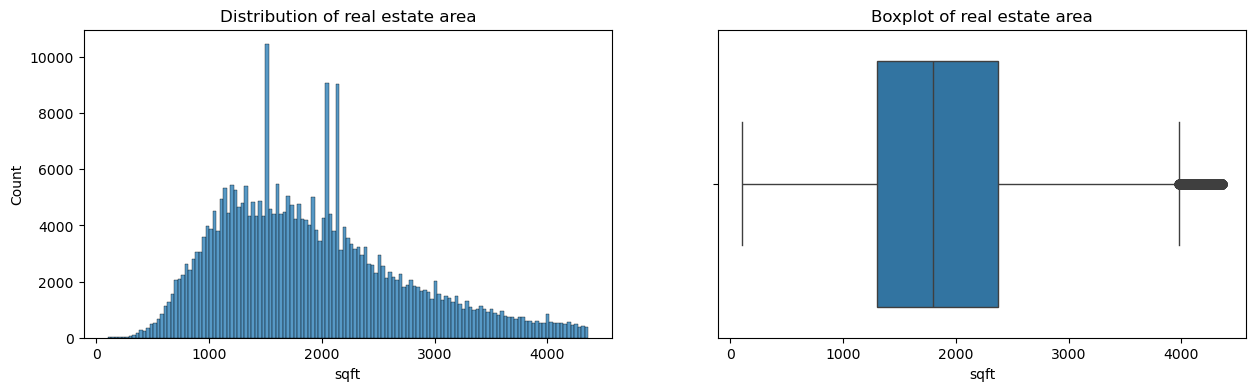

In [165]:
# Построим графики распределения признака 'sqft' 
# Let's plot the distribution graphs of the 'sqft' feature
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
histplot = sns.histplot(data=data, x='sqft', ax=axes[0]);
histplot.set_title('Distribution of real estate area');
boxplot = sns.boxplot(data=data, x='sqft', ax=axes[1]);
boxplot.set_title('Boxplot of real estate area');

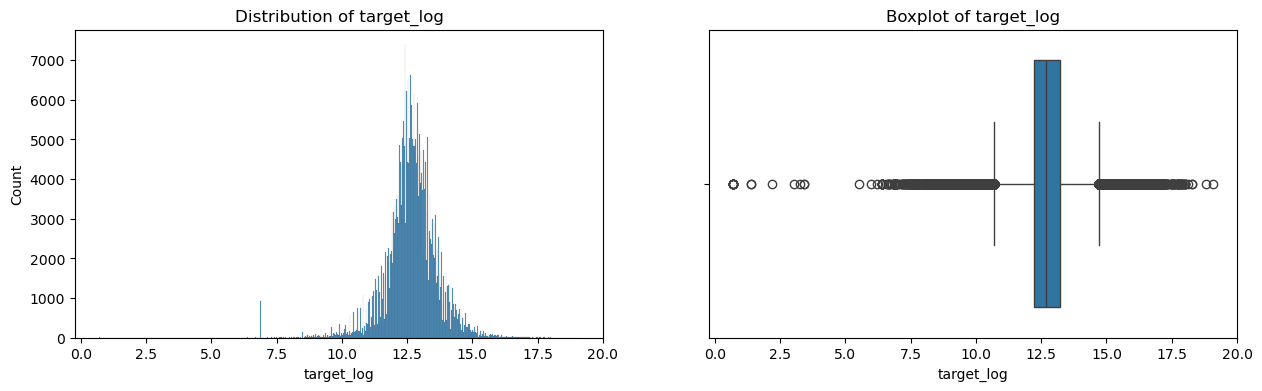

In [166]:
# Посмотрим лог-распределение целевой переменной 'target'
# Let's look at the log-distribution of the target variable 'target'
data['target_log'] = np.log1p(data['target'])

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
histplot = sns.histplot(data=data, x='target_log', ax=axes[0]);
histplot.set_title('Distribution of target_log');
boxplot = sns.boxplot(data=data, x='target_log', ax=axes[1]);
boxplot.set_title('Boxplot of target_log');

Из графиков видно, что присутствуют выбросы в целевой переменной, есть очень маленькие значения. Удалим их, это выглядит как явный мусор.

The graphs show that there are outliers in the target variable, including very small values. Let's remove them; they look like obvious junk.

In [167]:
data = data[data['target'] > 30000.0].reset_index(drop=True)

In [168]:
data['target'].min()

30070.0

In [169]:
# А также уберем самые большие значения (правый хвост), они могут повлиять на качество модели
# We will also remove the largest values (right tail), they can affect the quality of the model
data = data[data['target'] < data['target'].quantile(0.99)]

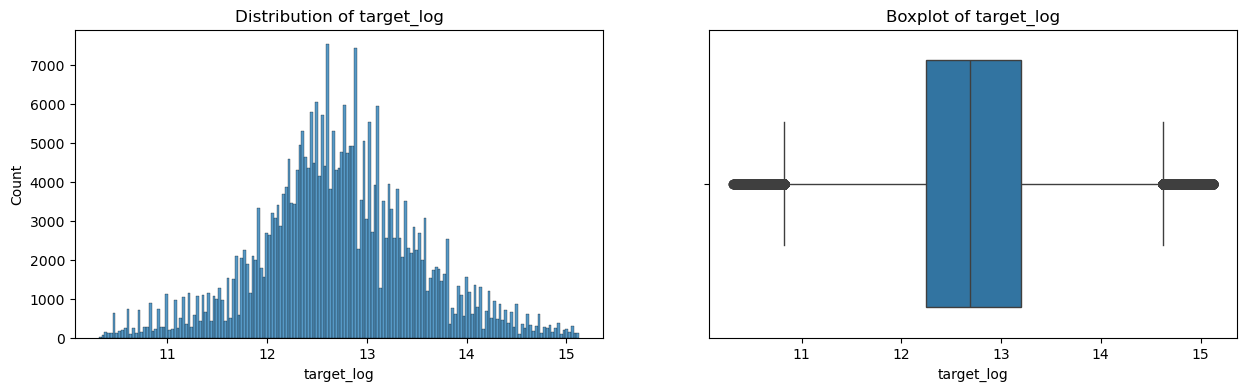

In [170]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
histplot = sns.histplot(data=data, x='target_log', ax=axes[0]);
histplot.set_title('Distribution of target_log');
boxplot = sns.boxplot(data=data, x='target_log', ax=axes[1]);
boxplot.set_title('Boxplot of target_log');

baths
count    313586.000000
mean          2.561233
std           0.844653
min           0.500000
25%           2.000000
50%           2.500000
75%           3.000000
max          15.000000
Name: baths, dtype: float64


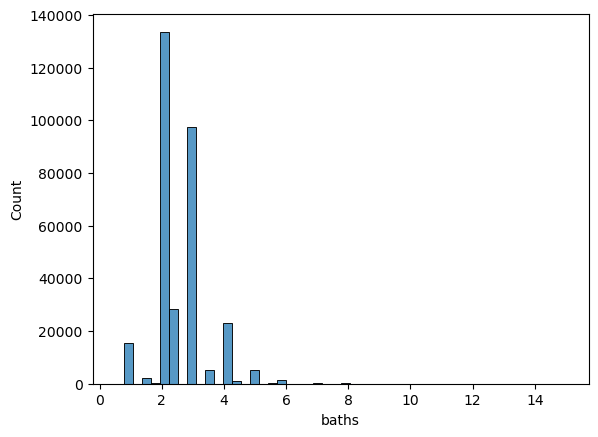

sqft
count    313586.000000
mean       1918.570944
std         814.939482
min         100.000000
25%        1300.000000
50%        1800.000000
75%        2382.000000
max        4361.000000
Name: sqft, dtype: float64


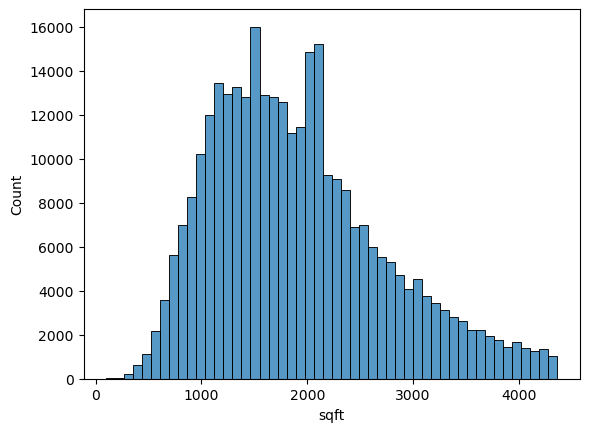

beds
count    313586.000000
mean          3.168506
std           0.984927
min           1.000000
25%           3.000000
50%           3.000000
75%           4.000000
max          20.000000
Name: beds, dtype: float64


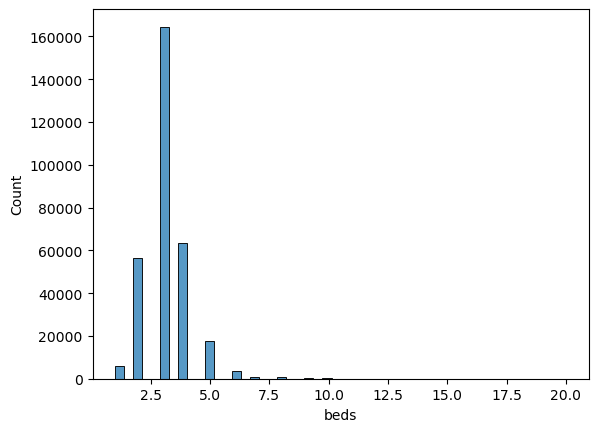

stories
count    313586.000000
mean          1.765834
std           1.114160
min           1.000000
25%           1.000000
50%           2.000000
75%           2.000000
max          10.000000
Name: stories, dtype: float64


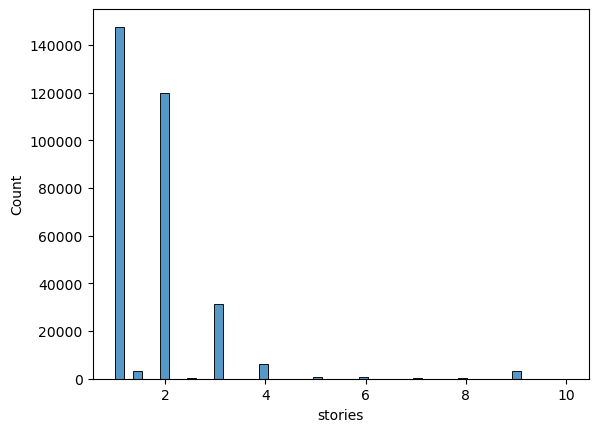

target
count    3.135860e+05
mean     4.617018e+05
std      4.534393e+05
min      3.007000e+04
25%      2.090000e+05
50%      3.250000e+05
75%      5.399000e+05
max      3.715000e+06
Name: target, dtype: float64


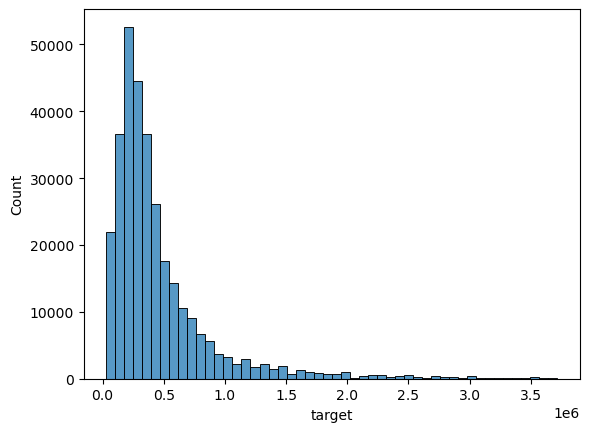

pool
count    313586.000000
mean          0.117601
std           0.322135
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: pool, dtype: float64


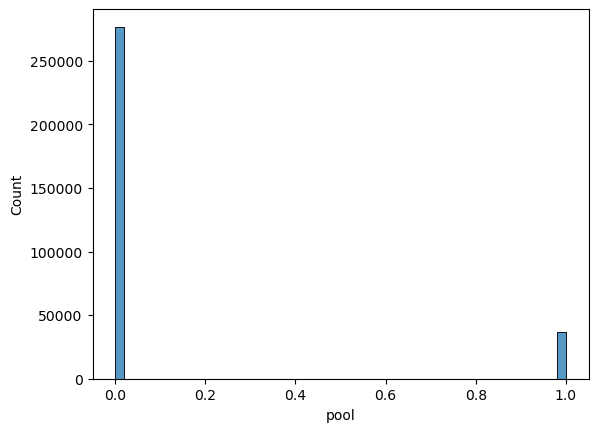

baths_missing
count    313586.000000
mean          0.266313
std           0.442031
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: baths_missing, dtype: float64


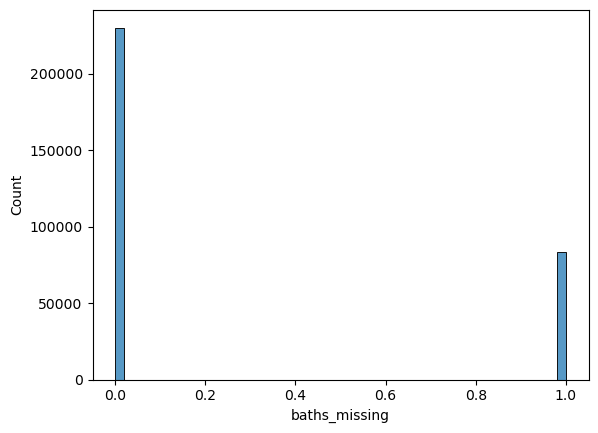

beds_missing
count    313586.000000
mean          0.235798
std           0.424497
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: beds_missing, dtype: float64


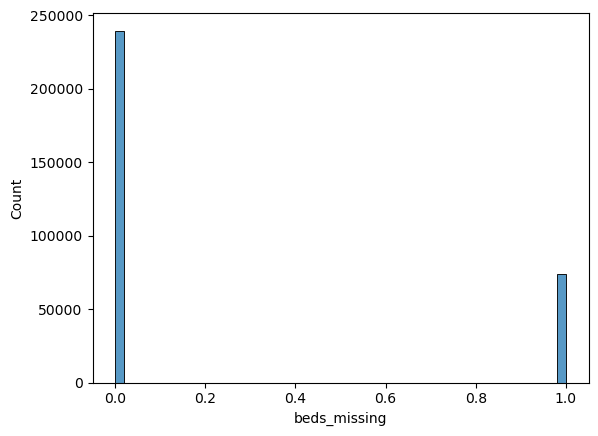

has_fireplace
count    313586.000000
mean          0.268628
std           0.443247
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: has_fireplace, dtype: float64


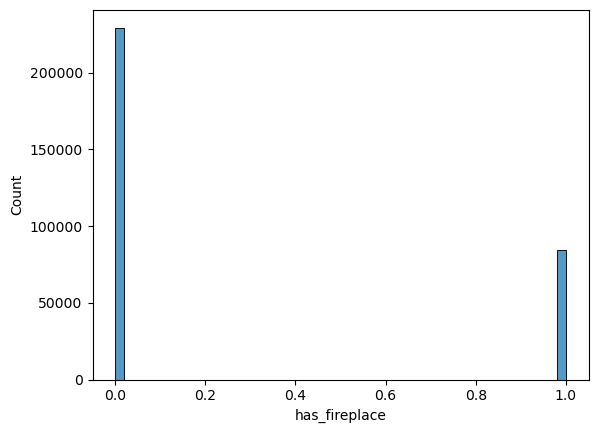

stories_missing
count    313586.000000
mean          0.387654
std           0.487216
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: stories_missing, dtype: float64


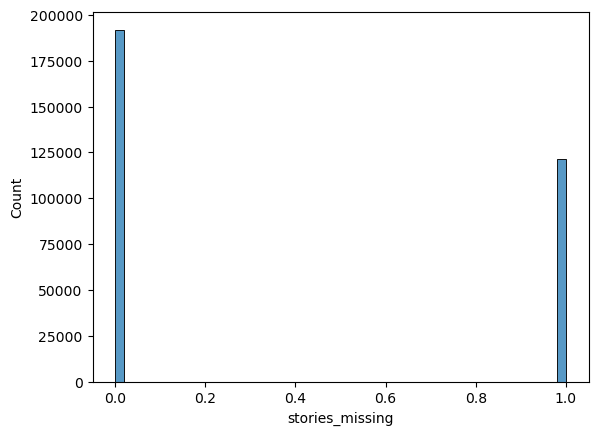

target_log
count    313586.000000
mean         12.715372
std           0.798624
min          10.311317
25%          12.250094
50%          12.691584
75%          13.199141
max          15.127890
Name: target_log, dtype: float64


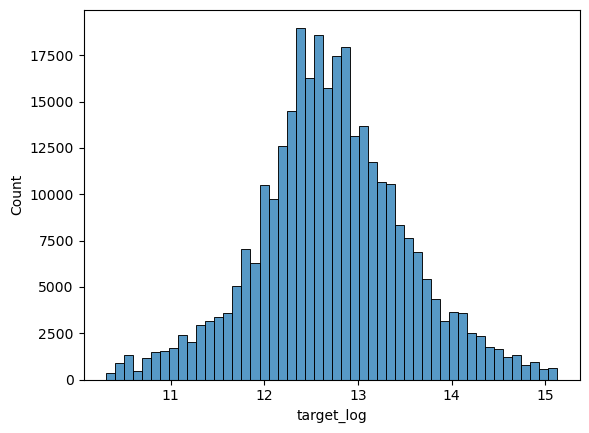

In [171]:
# Посмотрим распределения всех числовых признаков
# Let's look at the distribution of all numerical features

numeric_cols = data.select_dtypes(include='number').columns

for col in numeric_cols:
    print(col)
    print(data[col].describe())
    sns.histplot(data[col], bins=50)
    plt.show()

Давайте проанализируем наши признаки в зависимости от целевого признака. Сформулируем гипотезы и проверим их.

Let's analyze our features based on the target feature. Let's formulate hypotheses and test them.

#### С увеличением площади 'sqft' растёт стоимость недвижимости 'target_log'.

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): нет связи между 'sqft' и ценой

$$ H_0 : p = 0$$

*Альтернативная гипотеза* ($H_1$): есть положительная связь

$$ H_1 : p > 0$$

Так как распределение у нас не нормальное, есть выбросы, и нужно посмотреть связь между двумя переменными, то воспользуемся коэффициентом корреляции Spearman.

#### As area 'sqft' increases, real estate value 'target_log' increases.

**Formulate the null and alternative hypotheses**

*Null hypothesis* ($H_0$): There is no relationship between 'sqft' and price

$$ H_0 : p = 0$$

*Alternative hypothesis* ($H_1$): There is a positive relationship

$$ H_1 : p > 0$$

Since our distribution is not normal, there are outliers, and we need to look at the relationship between two variables, we will use the Spearman correlation coefficient.

In [172]:
# задаём уровень значимости
# set the significance level
alpha = 0.05 

# функция для принятия решения об отклонении нулевой гипотезы
# function for making a decision to reject the null hypothesis
def decision_hypothesis(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу в пользу альтернативной.'.format(alpha))
        print('The p-value is less than the specified significance level {:.2f}. Reject the null hypothesis in favor of the alternative.'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))
        print('The p-value is greater than the specified significance level {:.2f}. We have no reason to reject the null hypothesis.'.format(alpha))     

In [173]:
from scipy.stats import spearmanr

corr, p_value = spearmanr(data['sqft'], data['target_log'])

print(corr, p_value)
decision_hypothesis(p_value)

0.44591098109076666 0.0
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.
The p-value is less than the specified significance level 0.05. Reject the null hypothesis in favor of the alternative.


<Axes: xlabel='sqft', ylabel='target_log'>

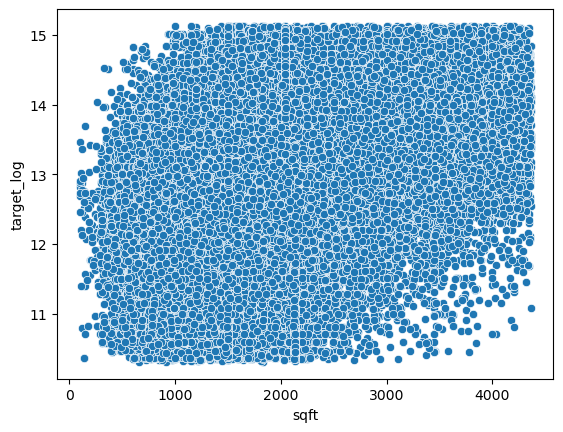

In [174]:
# Построим график
# Let's plot a graph
sns.scatterplot(x='sqft', y='target_log', data=data)

#### Вывод:

Можно сказать, что с увеличением площади 'sqft' растёт стоимость недвижимости 'target_log'. Это подтвердил статистический тест и график.

#### Conclusion:

It can be concluded that as the area (sqft) increases, the value of real estate (target_log) increases. This was confirmed by a statistical test and a graph.

#### С увеличением количества ванных комнат 'baths' растёт стоимость недвижимости 'target_log'

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): связи между 'baths' и 'target_log' нет

$$ H_0 : p = 0$$

*Альтернативная гипотеза* ($H_1$): есть положительная связь между 'baths' и 'target_log'

$$ H_1 : p > 0$$

Здесь тоже воспользуемся коэффициентом корреляции Spearman.

#### As the number of bathrooms increases, the value of real estate increases. 'target_log'

**Let's formulate the null and alternative hypotheses**

*Null hypothesis* ($H_0$): There is no relationship between 'baths' and 'target_log'

$$ H_0 : p = 0$$

*Alternative hypothesis* ($H_1$): There is a positive relationship between 'baths' and 'target_log'

$$ H_1 : p > 0$$

Here we will also use the Spearman correlation coefficient.

In [175]:
corr, p_value = spearmanr(data['baths'], data['target_log'])

print(corr, p_value)
decision_hypothesis(p_value)

0.3588917722870042 0.0
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.
The p-value is less than the specified significance level 0.05. Reject the null hypothesis in favor of the alternative.


<Axes: xlabel='baths', ylabel='target_log'>

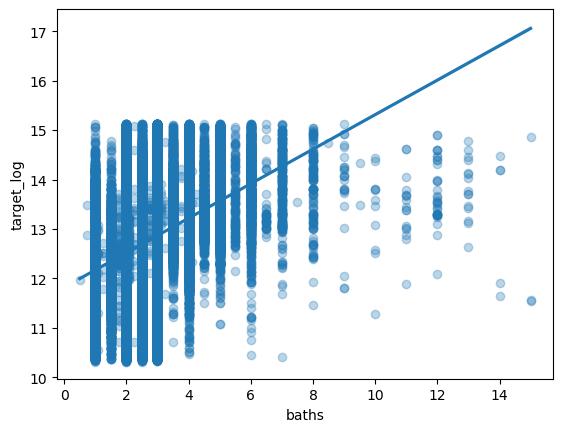

In [176]:
sns.regplot(x='baths', y='target_log', data=data, scatter_kws={'alpha': 0.3})

#### Вывод:

Обнаружена статистически значимая положительная связь между количеством ванных комнат и стоимостью недвижимости. С увеличением 'baths' стоимость 'target_log' в среднем возрастает.

#### Conclusion:

A statistically significant positive relationship was found between the number of bathrooms and property value. As the number of bathrooms increases, the value 'target_log' increases on average.

#### Стоимость недвижимости 'target_log' различается в зависимости от типа недвижимости 'property_type_clean'

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): распределения стоимости одинаковы для всех типов недвижимости

*Альтернативная гипотеза* ($H_1$): хотя бы один тип недвижимости имеет отличающееся распределение стоимости

Так как 'property_type_clean' — категориальный признак, у нас больше 2 групп, данные не нормальные и присутствуют выбросы, то используем Краскел-Уоллис тест.

#### Property value 'target_log' varies depending on property type 'property_type_clean'

**Formulate the null and alternative hypotheses**

*Null hypothesis* ($H_0$): the value distributions are the same for all property types

*Alternative hypothesis* ($H_1$): at least one property type has a different value distribution

Since 'property_type_clean' is a categorical variable, we have more than two groups, the data is not normal, and there are outliers, we use the Kruskal-Wallis test.

In [177]:
from scipy.stats import kruskal

groups = [
    group['target_log'].values
    for _, group in data.groupby('property_type_clean')
]

stat, p_value = kruskal(*groups)

print(f'p-value = {p_value:.5f}')
decision_hypothesis(p_value)

p-value = 0.00000
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.
The p-value is less than the specified significance level 0.05. Reject the null hypothesis in favor of the alternative.


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'single_family'),
  Text(1, 0, 'townhouse'),
  Text(2, 0, 'other'),
  Text(3, 0, 'unknown'),
  Text(4, 0, 'cooperative'),
  Text(5, 0, 'multi_family'),
  Text(6, 0, 'condo'),
  Text(7, 0, 'land'),
  Text(8, 0, 'mobile')])

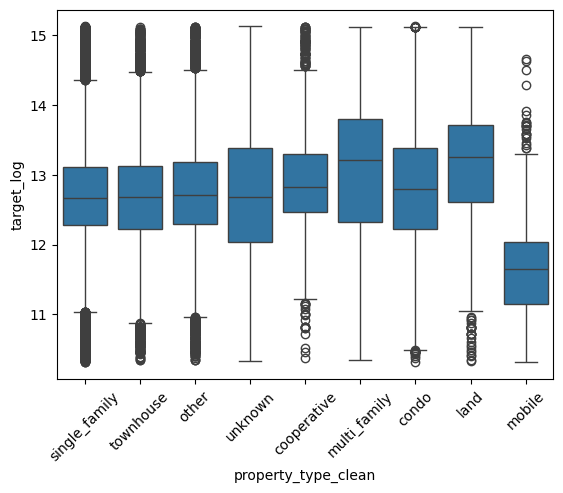

In [178]:
# Построим график
# Let's plot a graph
sns.boxplot(x='property_type_clean', y='target_log', data=data)
plt.xticks(rotation=45)

#### Вывод:

Обнаружены статистически значимые различия в стоимости недвижимости между различными типами недвижимости

#### Conclusion:

Statistically significant differences in property values ​​were found between different types of property.

#### Стоимость недвижимости 'target_log' различается в зависимости от города 'city'

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): распределения одинаковы во всех городах

*Альтернативная гипотеза* ($H_1$): есть различия хотя бы между некоторыми городами

Здесь тоже используем Краскел-Уоллис тест.

#### Property values 'target_log' vary depending on city 'city'

**Let's formulate the null and alternative hypotheses**

*Null hypothesis* ($H_0$): distributions are the same in all cities

*Alternative hypothesis* ($H_1$): there are differences between at least some cities

Here we also use the Kruskal-Wallis test.

In [179]:
# Так как городов довольно много, мы посмотрим только самые часто встречаемых
# Since there are quite a lot of cities, we will look at only the most frequently encountered ones
city_counts = data['city'].value_counts()
valid_cities = city_counts[city_counts >= 100].index

data_city = data[data['city'].isin(valid_cities)]

In [180]:
groups = [
    group['target_log'].values
    for _, group in data_city.groupby('city')
]

stat, p_value = kruskal(*groups)

print(f'p-value = {p_value:.5f}')
decision_hypothesis(p_value)

p-value = 0.00000
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.
The p-value is less than the specified significance level 0.05. Reject the null hypothesis in favor of the alternative.


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Houston'),
  Text(1, 0, 'Brooklyn'),
  Text(2, 0, 'Miami'),
  Text(3, 0, 'Jacksonville'),
  Text(4, 0, 'Charlotte'),
  Text(5, 0, 'Dallas'),
  Text(6, 0, 'Las Vegas'),
  Text(7, 0, 'Fort Worth'),
  Text(8, 0, 'San Antonio'),
  Text(9, 0, 'Chicago')])

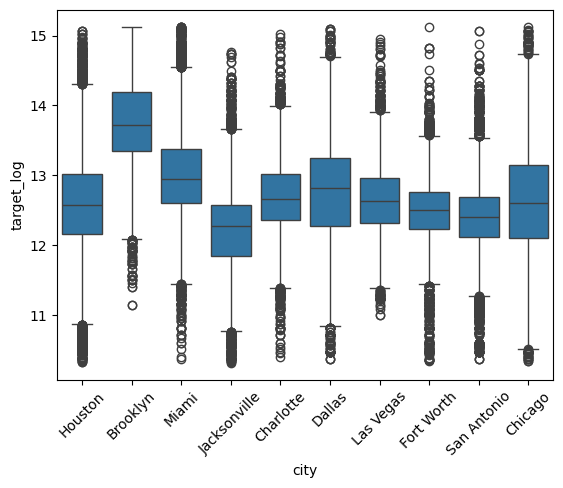

In [181]:
top_cities = data['city'].value_counts().head(10).index

sns.boxplot(
    data=data[data['city'].isin(top_cities)],
    x='city',
    y='target_log'
)
plt.xticks(rotation=45)

#### Вывод:

Обнаружены статистически значимые различия в стоимости недвижимости между городами.

#### Conclusion:

Statistically significant differences in property values were found between cities.

In [182]:
# Так как у нас много пропусков, мы создали флаги об их наличие. Давайте посмотрим влияют ли они на целевую переменную.
# Посмотрим разницу средних среди всех пропусков
# Since we have a lot of missing values, we've created flags for their presence. Let's see if they affect the target variable.
# Let's look at the difference in means among all missing values.
for col in ['baths_missing', 'beds_missing', 'stories_missing']:
    print(col)
    print(data.groupby(col)['target_log'].mean())
    print()

baths_missing
baths_missing
0    12.752433
1    12.613270
Name: target_log, dtype: float64

beds_missing
beds_missing
0    12.718990
1    12.703646
Name: target_log, dtype: float64

stories_missing
stories_missing
0    12.669235
1    12.788252
Name: target_log, dtype: float64



#### Наличие пропуска в признаке 'baths' влияет на стоимость недвижимости 'target_log'

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): нет различия между стоимостью недвижимости с пропусками и без пропусков

$$ H_0 : μ_0 = μ_1$$

*Альтернативная гипотеза* ($H_1$): есть различия между стоимостью недвижимости с пропусками и без пропусков

$$ H_0 : μ_0 \neq μ_1$$

У нас 2 незавсисимые группы, данные не нормальные - используем тест Манна-Уитни.

#### The presence of a gap in the 'baths' variable affects the value of real estate in the 'target_log' variable

**Formulate the null and alternative hypotheses**

*Null hypothesis* ($H_0$): There is no difference between the value of real estate with and without gaps

$$ H_0 : μ_0 = μ_1$$

*Alternative hypothesis* ($H_1$): There are differences between the value of real estate with and without gaps

$$ H_0 : μ_0 \neq μ_1$$

We have two independent groups, and the data is not normal—we use the Mann-Whitney test.

In [183]:
from scipy.stats import mannwhitneyu

x0 = data[data['baths_missing'] == 0]['target_log']
x1 = data[data['baths_missing'] == 1]['target_log']

stat, p_value = mannwhitneyu(x0, x1)

print(p_value)
decision_hypothesis(p_value)

0.0
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.
The p-value is less than the specified significance level 0.05. Reject the null hypothesis in favor of the alternative.


<Axes: xlabel='baths_missing', ylabel='target_log'>

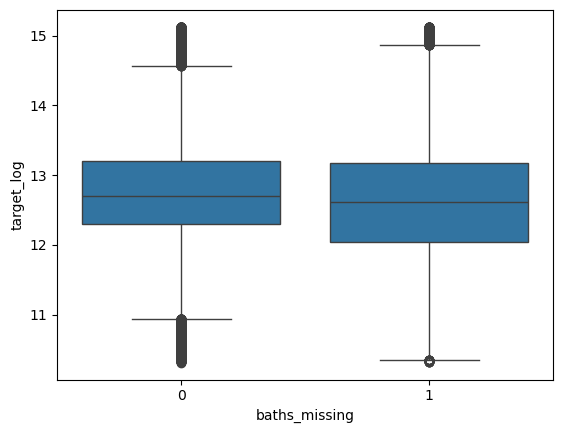

In [184]:
sns.boxplot(x='baths_missing', y='target_log', data=data)

#### Вывод:

Признаки пропусков являются информативными и будут использованы в модели

#### Conclusion:

The omission features are informative and will be used in the model.

### 3. Feature engineering

Вернемся к признакам 'homeFacts' и 'schools'. В них хранится много информации, попробуем достать ее.

Let's return to the 'homeFacts' and 'schools' features. They contain a lot of information, so let's try to extract it.

In [185]:
data['homeFacts'].value_counts().head(20)

homeFacts
{'atAGlanceFacts': [{'factValue': '', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': '', 'factLabel': 'Heating'}, {'factValue': '', 'factLabel': 'Cooling'}, {'factValue': '', 'factLabel': 'Parking'}, {'factValue': '—', 'factLabel': 'lotsize'}, {'factValue': None, 'factLabel': 'Price/sqft'}]}               5856
{'atAGlanceFacts': [{'factValue': None, 'factLabel': 'Year built'}, {'factValue': None, 'factLabel': 'Remodeled year'}, {'factValue': None, 'factLabel': 'Heating'}, {'factValue': None, 'factLabel': 'Cooling'}, {'factValue': None, 'factLabel': 'Parking'}, {'factValue': None, 'factLabel': 'lotsize'}, {'factValue': None, 'factLabel': 'Price/sqft'}]}    3096
{'atAGlanceFacts': [{'factValue': '', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': '', 'factLabel': 'Heating'}, {'factValue': '', 'factLabel': 'Cooling'}, {'factValue': '', 'factLabel': 'Parking'}, {'factValue': '-- sqft lot', 'f

In [186]:
data['schools'].value_counts().head(10)

schools
[{'rating': [], 'data': {'Distance': [], 'Grades': []}, 'name': []}]                                                                                                                                                                           2713
[{'rating': ['4/10', '5/10', '6/10'], 'data': {'Distance': ['39.69mi', '39.69mi', '39.69mi'], 'Grades': ['9-12', '6-8', 'PK-5']}, 'name': ['Fort Hancock High School', 'Fort Hancock Middle School', 'Benito Martinez Elementary School']}]     214
[{'rating': ['4/10', '6/10', '3/10'], 'data': {'Distance': ['3.62mi', '3.62mi', '3.62mi'], 'Grades': ['6-8', 'PK-5', '9-12']}, 'name': ['Horizon Middle School', 'Desert Hills Elementary School', 'Horizon High School']}]                     140
[{'rating': ['5/10', '3/10', '5/10'], 'data': {'Distance': ['9.71mi', '8.92mi', '1.56mi'], 'Grades': ['5-8', '9-12', 'K-4']}, 'name': ['Cheatham Middle School', 'Cheatham Co Central', 'West Cheatham Elementary School']}]                    132
[{'rating': ['10

In [187]:
# Обработаем признак 'schools'. Он представляет собой строку, внутри которой список словарей. Нужно превратить строку 
# в объект, чтобы достать необходимую нам информацию. Для этого используем ast
# Let's process the 'schools' attribute. It's a string containing a list of dictionaries. We need to convert the string
# into an object to get the information we need. For this, we'll use ast
import ast

# Напишем функцию для извлечения информации
# Let's write a function to extract information
def process_schools(schools):
    # преобразуем наши данные
    # transform our data
    try:
        tree = ast.literal_eval(schools)
    except:
        return np.nan, np.nan, np.nan

    # достаем количество школ
    # we get the number of schools
    try:
        school_count = len(tree[0]['name'])
    except:
        return np.nan, np.nan, np.nan

    # достаем ratings
    # get ratings
    try:
        rating = tree[0]['rating']
    except:
        return np.nan, np.nan, np.nan

    # берем нужное число для рейтинга
    # we take the required number for the rating
    clean_rating = []
    for x in rating:
        try:
            clean_rating.append(float(x.split('/')[0]))
        except:
            continue

    # количество валидных рейтингов
    # number of valid ratings
    valid_school_count = len(clean_rating)

    # находим средний рейтинг, и если отсутствуют данные, указываем это
    # we find the average rating, and if there is no data, we indicate this
    if len(clean_rating) == 0:
        average_rating = np.nan
    else:
        average_rating = sum(clean_rating) / len(clean_rating)

    # возвращаем число школ, средний рейтинг и валидное число школ с доступным рейтингом
    # return the number of schools, the average rating, and the valid number of schools with an available rating
    return average_rating, school_count, valid_school_count

data[['school_rating', 'school_count', 'valid_school_count']] = (data['schools'].apply(process_schools).apply(pd.Series))

In [188]:
data['school_rating'].describe()

count    310063.000000
mean          5.132760
std           1.918411
min           1.000000
25%           3.666667
50%           5.000000
75%           6.500000
max          10.000000
Name: school_rating, dtype: float64

In [189]:
data['school_count'].describe()

count    313586.000000
mean          4.166860
std           4.456547
min           0.000000
25%           3.000000
50%           3.000000
75%           4.000000
max          65.000000
Name: school_count, dtype: float64

In [190]:
data['valid_school_count'].describe()

count    313586.000000
mean          3.714732
std           4.286038
min           0.000000
25%           3.000000
50%           3.000000
75%           4.000000
max          65.000000
Name: valid_school_count, dtype: float64

In [191]:
data['school_rating'].isnull().sum()

3523

In [192]:
# Так как в наших данные есть пропуски, в признаке 'school_rating' тоже появились пропуски
# Заполним их медианной и создадим флаг об отсутствии данных
# Since our data contains gaps, the 'school_rating' feature also has gaps
# We'll fill them with the median and create a flag for missing data
data['school_rating_missing'] = data['school_rating'].isna().astype(int)
data['school_rating'] = data.groupby(['property_type_clean', 'state'])['school_rating'].transform(
lambda x: x.fillna(x.median()))

In [193]:
data['school_rating'].isnull().sum()

4

In [194]:
data = data.dropna(subset=['school_rating']).reset_index(drop=True)

In [195]:
# Удаляем уже ненужный признак 'schools'
# Remove the now unnecessary 'schools' attribute
data = data.drop(['schools'], axis=1)

In [196]:
# Обработаем признак 'homeFacts' по аналогу признака 'schools'
# Что можно достать: Year built, Remodeled year, lotsize, Heating, Cooling, Parking
# Price/sqft доставать не будем, так как в нем присутствует цена, а это наша целевая переменная
# We will process the 'homeFacts' feature similarly to the 'schools' feature
# What we can get: Year built, Remodeled year, lotsize, Heating, Cooling, Parking
# We won't extract Price/sqft, since it contains the price, and this is our target variable.
import re

# Начнем с года постройки и года реконструкции, сделаем функцию для этого
# Let's start with the year of construction and the year of reconstruction, let's make a function for this
def process_home_facts(home_facts):
    # преобразуем наши данные
    # transform our data
    try:
        tree = ast.literal_eval(home_facts)
    except:
        return np.nan, np.nan

    facts_dict = {item['factLabel']: item['factValue'] for item in tree['atAGlanceFacts']}

    # достаем Year built
    # we get Year built
    value = facts_dict.get('Year built')

    if value is None or value == '' or value == '—':
        year_built = np.nan
    else:
        value = str(value).strip()
        match = re.search(r'\d{4}', value)  # ищем год (4 цифры) # looking for the year (4 digits)
    
        if match:
            year_built = int(match.group())
        else:
            year_built = np.nan
            
    if year_built < 1600 or year_built > 2025:
        year_built = np.nan

    # достаем Remodeled year
    # we get Remodeled year
    value_2 = facts_dict.get('Remodeled year')

    if value_2 is None or value_2 == '' or value_2 == '—':
        remodeled_year = np.nan
    else:
        value_2 = str(value_2).strip()
        match_2 = re.search(r'\d{4}', value_2)  
        
        if match_2:
            remodeled_year = int(match_2.group())
        else:
            remodeled_year = np.nan
            
    if remodeled_year < 1600 or remodeled_year > 2026:
        remodeled_year = np.nan
        
    if not np.isnan(year_built) and not np.isnan(remodeled_year):
        if remodeled_year < year_built or remodeled_year > 2026:
            remodeled_year = np.nan
            
    return year_built, remodeled_year

data[['year_built', 'remodeled_year']] = data['homeFacts'].apply(process_home_facts).apply(pd.Series)

In [197]:
data[['year_built', 'remodeled_year']].describe()

,year_built,remodeled_year
count,282222.000000,134582.000000
mean,1979.922720,1982.625559
std,32.950413,24.518218
min,1703.000000,1853.000000
25%,1958.000000,1968.000000
50%,1985.000000,1986.000000
75%,2007.000000,2003.000000
max,2025.000000,2021.000000


In [198]:
data['year_built'].isnull().sum()

31360

In [199]:
# Заполним пропуски медианной и создадим флаг об отсутствии данных
# Fill in the blanks with the median and create a flag about missing data
data['year_built_missing'] = data['year_built'].isna().astype(int)
data['year_built'] = data['year_built'].fillna(data['year_built'].median())

In [200]:
# Теперь признак 'remodeled_year' сделаем бинарным
# Now we'll make the 'remodeled_year' attribute binary
data['is_remodeled'] = data['remodeled_year'].notna().astype(int)

# Удаляем уже ненужный признак 'remodeled_year'
# Remove the now unnecessary 'remodeled_year' attribute
data = data.drop(['remodeled_year'], axis=1)

In [201]:
# Создадим функцию, чтобы достать lotsize
# Let's create a function to get lotsize
def process_home_facts_2(home_facts):
    # преобразуем наши данные
    # transform our data
    try:
        tree = ast.literal_eval(home_facts)
    except:
        return np.nan

    facts_dict = {item['factLabel']: item['factValue'] for item in tree['atAGlanceFacts']}

    # достаем lotsize
    # we get lotsize
    value = facts_dict.get('lotsize')

    if value is None or value == '' or value == '—':
        lotsize = np.nan
    else:
        value = str(value).lower().replace(',', '').strip()
        
        # если acres → переводим в sqft
        # if acres → convert to sqft
        if 'acre' in value:
            match = re.search(r'\d+\.?\d*', value)
            lotsize = float(match.group()) * 43560 if match else np.nan
       
        # просто число (sqft или без единиц)
        # just a number (sqft or without units)
        else:
            match = re.search(r'\d+', value)
            lotsize = float(match.group()) if match else np.nan
                    
    return lotsize

data['lotsize'] = data['homeFacts'].apply(process_home_facts_2)

In [202]:
data['lotsize'].describe()

count    2.248170e+05
mean     8.296064e+04
std      4.568107e+06
min      1.000000e+00
25%      4.975000e+03
50%      7.501000e+03
75%      1.176120e+04
max      1.045508e+09
Name: lotsize, dtype: float64

In [203]:
# Уберем выбросы
# Let's remove emissions
data.loc[data['lotsize'] > 1e6, 'lotsize'] = np.nan
data.loc[data['lotsize'] == 0, 'lotsize'] = np.nan

In [204]:
data['lotsize'].describe()

count    223932.000000
mean      18891.955200
std       58704.009335
min           1.000000
25%        4961.000000
50%        7500.000000
75%       11326.000000
max      998395.200000
Name: lotsize, dtype: float64

In [205]:
# Заполним пропуски медианной и создадим флаг об отсутствии данных
# Fill in the blanks with the median and create a flag about missing data
data['lotsize_missing'] = data['lotsize'].isna().astype(int)
data['lotsize'] = data.groupby(['property_type_clean', 'state'])['lotsize'].transform(
lambda x: x.fillna(x.median()))
data['lotsize'] = data['lotsize'].fillna(data['lotsize'].median())

In [206]:
# Создадим функцию, чтобы достать Heating, Cooling, Parking
# Let's create a function to get Heating, Cooling, Parking
def process_home_facts_3(home_facts):
    # преобразуем наши данные
    # transform our data
    try:
        tree = ast.literal_eval(home_facts)
    except:
        return np.nan

    facts_dict = {item['factLabel']: item['factValue'] for item in tree['atAGlanceFacts']}

    # достаем Heating
    # we get Heating
    value = facts_dict.get('Heating')

    if value is None or value == '' or value == '—':
        heating = np.nan
    else:
        value = str(value).lower().strip()

        if 'electric' in value:
            heating = 'electric'
        elif 'gas' in value:
            heating = 'gas'
        else:
            heating = 'other'

    # достаем Cooling
    # we get Cooling
    value_2 = facts_dict.get('Cooling')
    
    if value_2 is None or value_2 == '' or value_2 == '—':
        has_cooling = np.nan
    else:
        value_2 = str(value_2).lower()
        
        if 'no' in value_2:
            has_cooling = 0
        elif 'cool' in value_2 or 'air' in value_2:
            has_cooling = 1
        else:
            has_cooling = np.nan

    # достаем Parking
    # we get Parking 
    value_3 = facts_dict.get('Parking')
    
    if value_3 is None or value_3 == '' or value_3 == '—':
        parking = np.nan
    else:
        value_3 = str(value_3).lower()
        match = re.search(r'\d+', value_3)
        
        if match:
            val = float(match.group())
    
            if val > 20:   # возьмем разумный лимит # let's take a reasonable limit
                parking = np.nan
            else:
                parking = val
        else:
            parking = np.nan
    
    return heating, has_cooling, parking

data[['heating', 'has_cooling', 'parking']] = data['homeFacts'].apply(process_home_facts_3).apply(pd.Series)

In [207]:
data[['has_cooling', 'parking']].describe()

,has_cooling,parking
count,48695.000000,58930.000000
mean,0.657234,2.000068
std,0.474639,1.235522
min,0.000000,0.000000
25%,0.000000,1.000000
50%,1.000000,2.000000
75%,1.000000,2.000000
max,1.000000,20.000000


In [208]:
data['heating'].describe()

count     239560
unique         3
top        other
freq      200426
Name: heating, dtype: object

In [209]:
# Заполним пропуски медианой и создадим флаг об отсутствии данных
# Fill in the blanks with the median and create a flag about missing data
data['parking_missing'] = data['parking'].isna().astype(int)
data['parking'] = data['parking'].fillna(data['parking'].median())

In [210]:
data['has_cooling'].isnull().sum()

264887

In [211]:
# Заполним пропуски нулем и создадим флаг об отсутствии данных
# Fill in the blanks with the zero and create a flag about missing data
data['has_cooling_missing'] = data['has_cooling'].isna().astype(int)
data['has_cooling'] = data['has_cooling'].fillna(0)

In [212]:
# Заполним пропуски в 'heating' значением 'unknown'
# Fill in the blanks in 'heating' with 'unknown'
data['heating'] = data['heating'].fillna('unknown')

In [213]:
# Удаляем уже ненужный признак 'homeFacts'
# Remove the now unnecessary 'homeFacts' attribute
data = data.drop(['homeFacts'], axis=1)

In [214]:
# Создадим новые признаки отношения площади к количеству ванных комнат и спален
# Let's create new indicators of the ratio of area to the number of bathrooms and bedrooms
data['sqft_per_bed'] = data['sqft'] / data['beds']
data['sqft_per_bath'] = data['sqft'] / data['baths']

In [215]:
data['sqft_log'] = np.log1p(data['sqft'])
data['lotsize_log'] = np.log1p(data['lotsize'])

#data = data.drop(['sqft', 'lotsize'], axis=1)

In [216]:
# Нам нужно закодировать категориальные признаки, посмотрим их описание
# We need to encode categorical features, let's look at their description
data.describe(include='object')

,city,zipcode,state,property_type_clean,status_clean,heating
count,313582,313582,313582,313582,313582,313582
unique,1852,4397,35,9,6,4
top,Houston,33131,FL,single_family,sale,other
freq,21516,1524,94721,174088,259542,200426


In [217]:
# Закодируем 'state' бинарным кодированием
# Encode 'state' using binary encoding
bin_encoder = ce.BinaryEncoder(cols=['state']) # столбец для кодирования # column for encoding
type_bin = bin_encoder.fit_transform(data['state'])
data = pd.concat([data, type_bin], axis=1)

data.head()

,baths,city,sqft,zipcode,beds,state,stories,target,pool,property_type_clean,...,sqft_per_bed,sqft_per_bath,sqft_log,lotsize_log,state_0,state_1,state_2,state_3,state_4,state_5
0,3.5,Southern Pines,2900.0,28387,4.0,NC,2.0,418000.0,0,single_family,...,725.000000,828.571429,7.972811,9.444099,0,0,0,0,0,1
1,3.0,Spokane Valley,1947.0,99216,3.0,WA,2.0,310000.0,0,single_family,...,649.000000,649.000000,7.574558,8.670601,0,0,0,0,1,0
2,2.0,Los Angeles,3000.0,90049,3.0,CA,1.0,2895000.0,1,single_family,...,1000.000000,1500.000000,8.006701,9.062652,0,0,0,0,1,1
3,3.0,Philadelphia,897.0,19145,2.0,PA,2.0,209000.0,0,townhouse,...,448.500000,299.000000,6.800170,6.523562,0,0,0,1,0,0
4,2.0,POINCIANA,1507.0,34759,3.0,FL,1.0,181500.0,0,other,...,502.333333,753.500000,7.318540,8.516593,0,0,0,1,0,1


In [218]:
# Закодируем 'property_type_clean', 'status_clean', 'heating' по типу OneHotEncoder, используя метод get_dummies()
# Encode 'property_type_clean', 'status_clean', 'heating' to the OneHotEncoder type using the get_dummies() method
data_encoded = pd.get_dummies(data, columns=['property_type_clean', 'status_clean', 'heating'])
data_encoded.head() 

,baths,city,sqft,zipcode,beds,state,stories,target,pool,baths_missing,...,status_clean_distressed,status_clean_other,status_clean_pending,status_clean_sale,status_clean_sold,status_clean_unknown,heating_electric,heating_gas,heating_other,heating_unknown
0,3.5,Southern Pines,2900.0,28387,4.0,NC,2.0,418000.0,0,0,...,False,False,False,True,False,False,False,False,True,False
1,3.0,Spokane Valley,1947.0,99216,3.0,WA,2.0,310000.0,0,0,...,False,False,False,True,False,False,False,False,False,True
2,2.0,Los Angeles,3000.0,90049,3.0,CA,1.0,2895000.0,1,0,...,False,False,False,True,False,False,False,False,True,False
3,3.0,Philadelphia,897.0,19145,2.0,PA,2.0,209000.0,0,1,...,False,False,False,True,False,False,False,False,True,False
4,2.0,POINCIANA,1507.0,34759,3.0,FL,1.0,181500.0,0,1,...,False,False,False,True,False,False,True,False,False,False


In [219]:
# Удаляем уже ненужный признак 'state'
# Remove the now unnecessary 'state' attribute
data_encoded = data_encoded.drop(['state'], axis=1)

In [220]:
# Закодируем частоту городов
# Let's encode the frequency of cities
city_counts = data_encoded['city'].value_counts()

data_encoded['city_freq'] = data_encoded['city'].map(city_counts) / len(data)

In [221]:
data_encoded['city'].value_counts().head(20)

city
Houston            21516
Miami              14601
San Antonio        14438
Jacksonville        9026
Dallas              7495
Brooklyn            6525
Chicago             5976
Charlotte           5649
Las Vegas           5229
Fort Worth          5028
Orlando             4696
Austin              4548
Fort Lauderdale     4512
New York            4489
Tampa               4336
Washington          4238
Nashville           4197
Philadelphia        4004
Cleveland           3682
Seattle             3597
Name: count, dtype: int64

In [222]:
# В 'city' есть города 'New York' и 'Brooklyn'. Объединим их в один город 'New York'
# 'city' contains the cities 'New York' and 'Brooklyn'. Let's combine them into one city 'New York'
data_encoded['city'] = data_encoded['city'].str.strip()

data_encoded.loc[data_encoded['city'].isin(['New York', 'Brooklyn']), 'city'] = 'New York'

In [223]:
# Закодируем не все города, а топ 20, а остальные добавим в 'other'
# We'll encode not all cities, but the top 20, and add the rest to 'other'
top_cities = data_encoded['city'].value_counts().head(20).index
data_encoded['city'] = data_encoded['city'].where(data_encoded['city'].isin(top_cities), 'other')

data_encoded = pd.get_dummies(data_encoded, columns=['city'], drop_first=True)

In [224]:
# Для 'zipcode' будем использовать frequency encoding, т.е. закодируем относительная частоту 
# For 'zipcode' we will use frequency encoding, i.e. we will encode the relative frequency
zip_freq = data_encoded['zipcode'].value_counts(normalize=True)
data_encoded['zipcode_freq'] = data_encoded['zipcode'].map(zip_freq)

# Удаляем уже ненужный признак 'zipcode'
# Remove the now unnecessary 'zipcode' attribute
data_encoded = data_encoded.drop(['zipcode'], axis=1)

In [225]:
data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 313582 entries, 0 to 313581
Data columns (total 75 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   baths                              313582 non-null  float64
 1   sqft                               313582 non-null  float64
 2   beds                               313582 non-null  float64
 3   stories                            313582 non-null  float64
 4   target                             313582 non-null  float64
 5   pool                               313582 non-null  int64  
 6   baths_missing                      313582 non-null  int64  
 7   beds_missing                       313582 non-null  int64  
 8   has_fireplace                      313582 non-null  int64  
 9   stories_missing                    313582 non-null  int64  
 10  target_log                         313582 non-null  float64
 11  school_rating                      3135

### 4. Анализ факторов, влияющих на стоимость недвижимости
### 4. Analyzing factors affecting real estate value

In [232]:
# Сделаем корреляционный анализ числовых признаков с целевым фактором
# Let's perform a correlation analysis of numerical features with the target factor
# Берем только числовые колонки
# We take only numerical columns
num_cols = [
    'sqft', 'lotsize', 'sqft_log', 'baths', 'beds', 'stories', 'school_rating', 'school_count', 'valid_school_count', 'year_built',
    'lotsize_log', 'parking', 'sqft_per_bed', 'sqft_per_bath', 'zipcode_freq'
]

# Считаем корреляцию (Spearman), так как в 'target_log' присутствуют выбросы
# We calculate the correlation (Spearman), since there are outliers in 'target_log'
corr = data_encoded[num_cols + ['target_log']].corr(method='spearman')
corr['target_log'].sort_values(ascending=False)

target_log            1.000000
sqft                  0.445916
sqft_log              0.445916
sqft_per_bed          0.396258
baths                 0.358911
school_rating         0.343230
beds                  0.195763
sqft_per_bath         0.190282
stories               0.176361
year_built            0.145059
parking               0.072708
zipcode_freq          0.026055
lotsize_log           0.002641
lotsize               0.002640
school_count         -0.015694
valid_school_count   -0.030095
Name: target_log, dtype: float64

<Axes: >

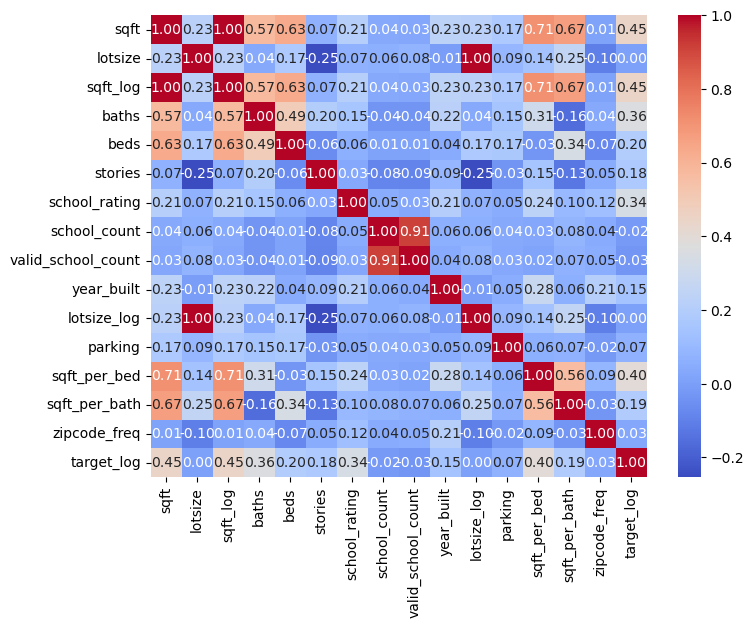

In [233]:
# Визуализируем 
# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')

По результатам корреляционного анализа было выявлено, что наибольшую связь с целевой переменной (target_log) демонстрируют признаки sqft, baths, sqft_per_bed и school_rating. Это указывает на то, что данные признаки являются наиболее информативными для предсказания стоимости недвижимости.

Также было установлено, что между числовыми признаками отсутствует сильная корреляция, что свидетельствует об отсутствии выраженной мультиколлинеарности.

На основании проведённого анализа все числовые признаки были сохранены для дальнейшего моделирования.

The correlation analysis revealed that the sqft, baths, sqft_per_bed and school_rating features demonstrated the strongest correlation with the target variable (target_log). This indicates that these features are the most informative for predicting real estate value.

It was also found that there was no strong correlation between the numerical features, indicating the absence of significant multicollinearity.

Based on this analysis, all numerical features were retained for further modeling.

In [228]:
# Теперь сделаем анализ бинарных признаков с целевым фактором
# Now let's do an analysis of binary features with the target factor
# Берем бинарные колонки
# We take binary columns
binary_cols = [
    'pool', 'baths_missing', 'beds_missing', 'has_fireplace', 'stories_missing', 'school_rating_missing', 'year_built_missing',
    'is_remodeled', 'lotsize_missing', 'has_cooling', 'parking_missing', 'has_cooling_missing'
]

for col in binary_cols:
    print(col)
    print(data_encoded.groupby(col)['target_log'].mean())
    print()

pool
pool
0    12.684071
1    12.950254
Name: target_log, dtype: float64

baths_missing
baths_missing
0    12.752432
1    12.613280
Name: target_log, dtype: float64

beds_missing
beds_missing
0    12.718989
1    12.703659
Name: target_log, dtype: float64

has_fireplace
has_fireplace
0    12.672231
1    12.832840
Name: target_log, dtype: float64

stories_missing
stories_missing
0    12.669234
1    12.788259
Name: target_log, dtype: float64

school_rating_missing
school_rating_missing
0    12.714820
1    12.764248
Name: target_log, dtype: float64

year_built_missing
year_built_missing
0    12.708774
1    12.774772
Name: target_log, dtype: float64

is_remodeled
is_remodeled
0    12.723506
1    12.704560
Name: target_log, dtype: float64

lotsize_missing
lotsize_missing
0    12.686769
1    12.786826
Name: target_log, dtype: float64

has_cooling
has_cooling
0.0    12.712556
1.0    12.740174
Name: target_log, dtype: float64

parking_missing
parking_missing
0    12.785115
1    12.699236
Name: 

Анализ бинарных признаков показал, что наличие дополнительных характеристик оказывает влияние на стоимость недвижимости.
Таким образом, бинарные признаки являются информативными и могут быть использованы при построении модели.

An analysis of binary features showed that the presence of additional characteristics influences property value.
Thus, binary features are informative and can be used in model construction.

In [229]:
# Теперь сделаем анализ булевых признаков с целевым фактором
# Now let's do an analysis of bool features with the target factor
# Берем булевые колонки
# We take bool columns
bool_cols = data_encoded.select_dtypes(include='bool').columns.tolist()

for col in bool_cols:
    print(col)
    print(data_encoded.groupby(col)['target_log'].mean())
    print()

property_type_clean_condo
property_type_clean_condo
False    12.697489
True     12.833854
Name: target_log, dtype: float64

property_type_clean_cooperative
property_type_clean_cooperative
False    12.713592
True     12.925024
Name: target_log, dtype: float64

property_type_clean_land
property_type_clean_land
False    12.714582
True     13.099415
Name: target_log, dtype: float64

property_type_clean_mobile
property_type_clean_mobile
False    12.726567
True     11.614449
Name: target_log, dtype: float64

property_type_clean_multi_family
property_type_clean_multi_family
False    12.704855
True     13.017896
Name: target_log, dtype: float64

property_type_clean_other
property_type_clean_other
False    12.712656
True     12.746201
Name: target_log, dtype: float64

property_type_clean_single_family
property_type_clean_single_family
False    12.748991
True     12.688438
Name: target_log, dtype: float64

property_type_clean_townhouse
property_type_clean_townhouse
False    12.718168
True     12

Несмотря на то, что средние значения целевой переменной в логарифмическом масштабе отличаются незначительно, даже небольшие различия (на уровне 0.05–0.1) соответствуют существенным изменениям в исходной цене недвижимости.
Таким образом, булевые признаки оказывают влияние на целевую переменную и являются информативными для модели.

Although the mean values of the target variable on a logarithmic scale differ only slightly, even small differences (at the 0.05–0.1 level) correspond to significant changes in the initial property price.
Thus, the Boolean features influence the target variable and are informative for the model.

### 5.Построение и обучение моделей
### 5. Building and training models

In [234]:
# Для начала построим baseline модель линейную регрессию
# First, let's build a baseline model LinearRegression

# Разбиваем датафрейм на части, необходимые для обучения и тестирования модели
# split the dataframe into parts necessary for training and testing the model
X = data_encoded.drop(['target_log', 'target'], axis = 1)  
y = data_encoded['target_log'] 

In [235]:
# Для тестирования мы будем использовать 25% от исходного датасета
# For testing, we will use 25% of the original dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [236]:
# Масштабируем числовые признаки
# We scale the numerical features

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [237]:
# Создаём объект класса LinearRegression
# Create an object of the LinearRegression class
lr_model = linear_model.LinearRegression()

# Обучаем модель
# Train the model
lr_model.fit(X_train, y_train)
 
# Делаем предсказание для тренировочной выборки
# Making a prediction for the training set
y_train_predict = lr_model.predict(X_train)

# Делаем предсказание для тестовой выборки
# Making a prediction for the test sample
y_test_predict = lr_model.predict(X_test)

# Выводим метрики в лог-пространстве, так как 'target_log'
# We display metrics in log space, since 'target_log'
mae_train = metrics.mean_absolute_error(y_train, y_train_predict)
print(f"Train MAE: {mae_train:.3f}")
mae_test = metrics.mean_absolute_error(y_test, y_test_predict)
print(f"Test MAE: {mae_test:.3f}")

rmse_train = np.sqrt(metrics.mean_squared_error(y_train, y_train_predict))
print(f"Train RMSE: {rmse_train:.3f}")
rmse_test = np.sqrt(metrics.mean_squared_error(y_test, y_test_predict))
print(f"Test RMSE: {rmse_test:.3f}")

r2_train = metrics.r2_score(y_train, y_train_predict)
print(f"Train R2: {r2_train:.3f}")
r2_test = metrics.r2_score(y_test, y_test_predict)
print(f"Test R2: {r2_test:.3f}")

Train MAE: 0.407
Test MAE: 0.406
Train RMSE: 0.542
Test RMSE: 0.540
Train R2: 0.540
Test R2: 0.542


#### Вывод:

Качество модели оценивалось с использованием метрик MAE, RMSE и коэффициента детерминации $R^2$.
Значение $R^2$ показывает долю дисперсии целевой переменной, объяснённую моделью, и позволяет оценить общее качество предсказания.

Базовая модель линейной регрессии продемонстрировала среднее качество: коэффициент детерминации $R^2$ составил около 0.51, что означает, что модель объясняет примерно 51% вариации стоимости недвижимости.

Значения метрик на обучающей и тестовой выборках практически совпадают, что свидетельствует об отсутствии переобучения.

Однако относительно высокие значения MAE и RMSE указывают на то, что модель допускает значительную ошибку в предсказаниях, что оставляет пространство для улучшения.

#### Conclusion:

Model quality was assessed using the MAE, RMSE, and $R^2$ metrics.
$R^2$ quantifies the proportion of the target variable's variance explained by the model and allows one to assess the overall prediction quality.

The baseline linear regression model demonstrated average quality: $R^2$ quantified approximately 0.51, meaning the model explains approximately 51% of the property value variance.

The metric values for the training and test sets are virtually identical, indicating the absence of overfitting.

However, relatively high MAE and RMSE values indicate that the model makes a significant prediction error, leaving room for improvement.

In [238]:
# Попробуем улучшить модель линейной регрессии, используя L1-регуляризацию
# Let's try to improve the linear regression model using L1 regularization
# Для этого масштабируем признаки
# To do this, we scale the features

X = data_encoded.drop(['target_log', 'target'], axis = 1)  
y = data_encoded['target_log'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso_lr = linear_model.Lasso(alpha=0.01, max_iter=2000, random_state=42)
lasso_lr.fit(X_train_scaled, y_train)
 
y_train_predict = lasso_lr.predict(X_train_scaled)
y_test_predict = lasso_lr.predict(X_test_scaled)

# Выводим метрики в лог-пространстве, так как 'target_log'
# We display metrics in log space, since 'target_log'
mae_train = metrics.mean_absolute_error(y_train, y_train_predict)
print(f"Train MAE: {mae_train:.3f}")
mae_test = metrics.mean_absolute_error(y_test, y_test_predict)
print(f"Test MAE: {mae_test:.3f}")

rmse_train = np.sqrt(metrics.mean_squared_error(y_train, y_train_predict))
print(f"Train RMSE: {rmse_train:.3f}")
rmse_test = np.sqrt(metrics.mean_squared_error(y_test, y_test_predict))
print(f"Test RMSE: {rmse_test:.3f}")

r2_train = metrics.r2_score(y_train, y_train_predict)
print(f"Train R2: {r2_train:.3f}")
r2_test = metrics.r2_score(y_test, y_test_predict)
print(f"Test R2: {r2_test:.3f}")

Train MAE: 0.413
Test MAE: 0.412
Train RMSE: 0.551
Test RMSE: 0.549
Train R2: 0.525
Test R2: 0.527


In [118]:
# А теперь посторим модель на полиномиальных признаках
# Now let's build a model on polynomial features

# Создаём генератор полиномиальных признаков
# Create a polynomial feature generator
poly = preprocessing.PolynomialFeatures(degree=2, include_bias=False)
poly.fit(X_train_scaled)

X_train_poly = poly.transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print(X_train_poly.shape)
print(X_test_poly.shape)

(235186, 2627)
(78396, 2627)


In [119]:
# Создаём объект класса линейной регрессии с L1-регуляризацией с валидацией
# Create an object of the linear regression class with L1 regularization with validation
from sklearn.linear_model import LassoCV

lasso_lr_poly = linear_model.LassoCV(cv=5, random_state=42)
lasso_lr_poly.fit(X_train_poly, y_train)
 
y_train_predict = lasso_lr_poly.predict(X_train_poly)
y_test_predict = lasso_lr_poly.predict(X_test_poly)

# Выводим метрики в лог-пространстве, так как 'target_log'
# We display metrics in log space, since 'target_log'
mae_train = metrics.mean_absolute_error(y_train, y_train_predict)
print(f"Train MAE: {mae_train:.3f}")
mae_test = metrics.mean_absolute_error(y_test, y_test_predict)
print(f"Test MAE: {mae_test:.3f}")

rmse_train = np.sqrt(metrics.mean_squared_error(y_train, y_train_predict))
print(f"Train RMSE: {rmse_train:.3f}")
rmse_test = np.sqrt(metrics.mean_squared_error(y_test, y_test_predict))
print(f"Test RMSE: {rmse_test:.3f}")

r2_train = metrics.r2_score(y_train, y_train_predict)
print(f"Train R2: {r2_train:.3f}")
r2_test = metrics.r2_score(y_test, y_test_predict)
print(f"Test R2: {r2_test:.3f}")

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.472e+01, tolerance: 1.202e+01
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.257e+01, tolerance: 1.501e+01
  model = cd_fast.enet_coordinate_descent(


Train MAE: 0.320
Test MAE: 0.320
Train RMSE: 0.443
Test RMSE: 0.443
Train R2: 0.692
Test R2: 0.691


Проведённый анализ показал, что линейные модели Linear Regression демонстрируют невысокое качество (R² ≈ 0.54).
Это указывает на наличие сложных нелинейных зависимостей в данных, которые не могут быть адекватно описаны линейной моделью.
После использования полиномиальных признаков качество линейной модели значительно улучшилось (R² ≈ 0.69).Это подтверждает, что исходная зависимость между признаками и целевой переменной является нелинейной, и её можно частично аппроксимировать с помощью расширения признакового пространства.

The analysis showed that the Linear Regression models exhibited poor performance (R² ≈ 0.54).
This indicates the presence of complex nonlinear relationships in the data that cannot be adequately described by a linear model.
After using polynomial features, the performance of the linear model improved significantly (R² ≈ 0.69). This confirms that the original relationship between the features and the target variable is nonlinear and can be partially approximated by expanding the feature space.

In [128]:
# Создаем модель случайного леса с заданными параметрами
# Create a random forest model with the given parameters
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

# Выводим метрики в лог-пространстве, так как 'target_log'
# We display metrics in log space, since 'target_log'
mae_train = metrics.mean_absolute_error(y_train, y_pred_train)
print(f"Train MAE: {mae_train:.3f}")
mae_test = metrics.mean_absolute_error(y_test, y_pred_test)
print(f"Test MAE: {mae_test:.3f}")

rmse_train = np.sqrt(metrics.mean_squared_error(y_train, y_pred_train))
print(f"Train RMSE: {rmse_train:.3f}")
rmse_test = np.sqrt(metrics.mean_squared_error(y_test, y_pred_test))
print(f"Test RMSE: {rmse_test:.3f}")

r2_train = metrics.r2_score(y_train, y_pred_train)
print(f"Train R2: {r2_train:.3f}")
r2_test = metrics.r2_score(y_test, y_pred_test)
print(f"Test R2: {r2_test:.3f}")

Train MAE: 0.171
Test MAE: 0.239
Train RMSE: 0.259
Test RMSE: 0.356
Train R2: 0.895
Test R2: 0.801


In [129]:
from sklearn.ensemble import GradientBoostingRegressor

# Создаем объект класса градиентный бустинг
# Create an object of the gradient boosting class
gb = GradientBoostingRegressor(
    max_depth=10, 
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

# Обучаем модель
# Train the model
gb.fit(X_train, y_train)

# Формируем предсказание для тренировочной и тестовой выборки
# Form a prediction for the training and test samples
gb_pred_train = gb.predict(X_train)
gb_pred_test = gb.predict(X_test)

# Выводим метрики в лог-пространстве, так как 'target_log'
# We display metrics in log space, since 'target_log'
mae_train = metrics.mean_absolute_error(y_train, gb_pred_train)
print(f"Train MAE: {mae_train:.3f}")
mae_test = metrics.mean_absolute_error(y_test, gb_pred_test)
print(f"Test MAE: {mae_test:.3f}")

rmse_train = np.sqrt(metrics.mean_squared_error(y_train, gb_pred_train))
print(f"Train RMSE: {rmse_train:.3f}")
rmse_test = np.sqrt(metrics.mean_squared_error(y_test, gb_pred_test))
print(f"Test RMSE: {rmse_test:.3f}")

r2_train = metrics.r2_score(y_train, gb_pred_train)
print(f"Train R2: {r2_train:.3f}")
r2_test = metrics.r2_score(y_test, gb_pred_test)
print(f"Test R2: {r2_test:.3f}")

Train MAE: 0.176
Test MAE: 0.218
Train RMSE: 0.257
Test RMSE: 0.322
Train R2: 0.896
Test R2: 0.837


In [120]:
# Попробуем создать модель XGBRegressor
# Let's try to create XGBRegressor model
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_train = xgb.predict(X_train)
y_pred_test = xgb.predict(X_test)

mae_train = metrics.mean_absolute_error(y_train, y_pred_train)
print(f"Train MAE: {mae_train:.3f}")
mae_test = metrics.mean_absolute_error(y_test, y_pred_test)
print(f"Test MAE: {mae_test:.3f}")

rmse_train = np.sqrt(metrics.mean_squared_error(y_train, y_pred_train))
print(f"Train RMSE: {rmse_train:.3f}")
rmse_test = np.sqrt(metrics.mean_squared_error(y_test, y_pred_test))
print(f"Test RMSE: {rmse_test:.3f}")

r2_train = metrics.r2_score(y_train, y_pred_train)
print(f"Train R2: {r2_train:.3f}")
r2_test = metrics.r2_score(y_test, y_pred_test)
print(f"Test R2: {r2_test:.3f}")

Train MAE: 0.217
Test MAE: 0.240
Train RMSE: 0.315
Test RMSE: 0.348
Train R2: 0.845
Test R2: 0.809


In [118]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=500,
    depth=15,
    learning_rate=0.05,
    verbose=0,
    random_state=42
)

cat.fit(X_train, y_train)

y_pred_train = cat.predict(X_train)
y_pred_test = cat.predict(X_test)

mae_train = metrics.mean_absolute_error(y_train, y_pred_train)
print(f"Train MAE: {mae_train:.3f}")
mae_test = metrics.mean_absolute_error(y_test, y_pred_test)
print(f"Test MAE: {mae_test:.3f}")

rmse_train = np.sqrt(metrics.mean_squared_error(y_train, y_pred_train))
print(f"Train RMSE: {rmse_train:.3f}")
rmse_test = np.sqrt(metrics.mean_squared_error(y_test, y_pred_test))
print(f"Test RMSE: {rmse_test:.3f}")

r2_train = metrics.r2_score(y_train, y_pred_train)
print(f"Train R2: {r2_train:.3f}")
r2_test = metrics.r2_score(y_test, y_pred_test)
print(f"Test R2: {r2_test:.3f}")

Train MAE: 0.188
Test MAE: 0.221
Train RMSE: 0.278
Test RMSE: 0.327
Train R2: 0.879
Test R2: 0.832


In [123]:
from sklearn.model_selection import RandomizedSearchCV

# Попробуем улучшить модель градиентного бустинга подбором гиперпараметров
# Let's try to improve the gradient boosting model by selecting hyperparameters
gb = GradientBoostingRegressor(random_state=42)

# Сетка параметров
# Parameter grid
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [1, 2, 5, 10],
    'subsample': [0.6, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist,
    n_iter=20,              
    scoring='r2',
    cv=3,                  
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Возьмем подвыборку для ускорения работы
# Let's take a subsample to speed up the work
X_sample = X_train.sample(50000, random_state=42)
y_sample = y_train.loc[X_sample.index]

# обучение
random_search.fit(X_sample, y_sample)
print("Best params:", random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'subsample': 0.8, 'n_estimators': 400, 'min_samples_leaf': 1, 'max_depth': 10, 'learning_rate': 0.05}


In [124]:
# Обучаем модель на подобранных параметрах
# Train the model using the selected parameters
best_gb = random_search.best_estimator_

# Формируем предсказание для тренировочной и тестовой выборки
# Form a prediction for the training and test samples
gb_pred_train = best_gb.predict(X_train)
gb_pred_test = best_gb.predict(X_test)

# Выводим метрики в лог-пространстве, так как 'target_log'
# We display metrics in log space, since 'target_log'
mae_train = metrics.mean_absolute_error(y_train, gb_pred_train)
print(f"Train MAE: {mae_train:.3f}")
mae_test = metrics.mean_absolute_error(y_test, gb_pred_test)
print(f"Test MAE: {mae_test:.3f}")

rmse_train = np.sqrt(metrics.mean_squared_error(y_train, gb_pred_train))
print(f"Train RMSE: {rmse_train:.3f}")
rmse_test = np.sqrt(metrics.mean_squared_error(y_test, gb_pred_test))
print(f"Test RMSE: {rmse_test:.3f}")

r2_train = metrics.r2_score(y_train, gb_pred_train)
print(f"Train R2: {r2_train:.3f}")
r2_test = metrics.r2_score(y_test, gb_pred_test)
print(f"Test R2: {r2_test:.3f}")

Train MAE: 0.218
Test MAE: 0.241
Train RMSE: 0.330
Test RMSE: 0.355
Train R2: 0.830
Test R2: 0.802


In [120]:
import optuna
# Попробуем улучшить модель CatBoost подбором гиперпараметров
# Let's try to improve the CatBoost model by selecting hyperparameters

def optuna_rf(trial):
    # задаем пространства поиска гиперпараметров
    # define the hyperparameter search spaces
    iterations = trial.suggest_int('iterations', 300, 600)
    max_depth = trial.suggest_int('depth', 10, 16)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2)

    # создаем модель
    # create a model
    model = CatBoostRegressor(iterations=iterations,
                              depth=max_depth,
                              learning_rate=learning_rate,
                              random_state=42)
    # обучаем модель
    # train the model
    model.fit(X_train, y_train)
    mae_test = metrics.mean_absolute_error(y_test, model.predict(X_test))
    
    return mae_test

In [134]:
%%time
# cоздаем объект исследования
# creating a research object
# можем напрямую указать, что нам необходимо минимизировать метрику direction="minimize"
# we can directly indicate that we need to minimize the metric direction="minimize"
study = optuna.create_study(direction="minimize")

# ищем лучшую комбинацию гиперпараметров n_trials раз
# looking for the best combination of hyperparameters n_trials times
study.optimize(optuna_rf, n_trials=20)

[I 2026-05-05 16:50:25,617] A new study created in memory with name: no-name-213bfff0-e5ca-464a-806d-7d4fd25af74d


0:	learn: 0.7322337	total: 348ms	remaining: 3m 12s
1:	learn: 0.6786568	total: 715ms	remaining: 3m 17s
2:	learn: 0.6322204	total: 1.1s	remaining: 3m 21s
3:	learn: 0.5959916	total: 1.41s	remaining: 3m 14s
4:	learn: 0.5654790	total: 1.75s	remaining: 3m 12s
5:	learn: 0.5433835	total: 2.07s	remaining: 3m 9s
6:	learn: 0.5249412	total: 2.42s	remaining: 3m 9s
7:	learn: 0.5069168	total: 2.79s	remaining: 3m 10s
8:	learn: 0.4939231	total: 3.13s	remaining: 3m 10s
9:	learn: 0.4803586	total: 3.47s	remaining: 3m 9s
10:	learn: 0.4715504	total: 3.86s	remaining: 3m 10s
11:	learn: 0.4623455	total: 4.16s	remaining: 3m 8s
12:	learn: 0.4552567	total: 4.54s	remaining: 3m 9s
13:	learn: 0.4475795	total: 4.84s	remaining: 3m 7s
14:	learn: 0.4427772	total: 5.17s	remaining: 3m 6s
15:	learn: 0.4383017	total: 5.52s	remaining: 3m 5s
16:	learn: 0.4338068	total: 5.86s	remaining: 3m 5s
17:	learn: 0.4302599	total: 6.21s	remaining: 3m 5s
18:	learn: 0.4273108	total: 6.54s	remaining: 3m 4s
19:	learn: 0.4233091	total: 6.87s	

[I 2026-05-05 16:53:33,964] Trial 0 finished with value: 0.20213342738847367 and parameters: {'iterations': 555, 'depth': 14, 'learning_rate': 0.16241023698107765}. Best is trial 0 with value: 0.20213342738847367.


0:	learn: 0.7132396	total: 2.17s	remaining: 17m 36s
1:	learn: 0.6453664	total: 3.68s	remaining: 14m 54s
2:	learn: 0.5939852	total: 5.03s	remaining: 13m 33s
3:	learn: 0.5572028	total: 6.31s	remaining: 12m 43s
4:	learn: 0.5242182	total: 7.55s	remaining: 12m 9s
5:	learn: 0.5030055	total: 8.85s	remaining: 11m 50s
6:	learn: 0.4839770	total: 10.2s	remaining: 11m 40s
7:	learn: 0.4675829	total: 11.6s	remaining: 11m 34s
8:	learn: 0.4548740	total: 12.8s	remaining: 11m 21s
9:	learn: 0.4426098	total: 14.1s	remaining: 11m 13s
10:	learn: 0.4341193	total: 15.3s	remaining: 11m 4s
11:	learn: 0.4269528	total: 16.7s	remaining: 11m 1s
12:	learn: 0.4208174	total: 17.9s	remaining: 10m 54s
13:	learn: 0.4148441	total: 19.2s	remaining: 10m 48s
14:	learn: 0.4104127	total: 20.5s	remaining: 10m 45s
15:	learn: 0.4059355	total: 21.7s	remaining: 10m 40s
16:	learn: 0.4011110	total: 22.9s	remaining: 10m 35s
17:	learn: 0.3975148	total: 24.2s	remaining: 10m 31s
18:	learn: 0.3948191	total: 25.4s	remaining: 10m 27s
19:	le

[I 2026-05-05 17:04:02,402] Trial 1 finished with value: 0.20226548449004705 and parameters: {'iterations': 488, 'depth': 16, 'learning_rate': 0.19999633435336545}. Best is trial 0 with value: 0.20213342738847367.


...

0:	learn: 0.7390411	total: 535ms	remaining: 4m 35s
1:	learn: 0.6886177	total: 1.18s	remaining: 5m 1s
2:	learn: 0.6449681	total: 1.81s	remaining: 5m 9s
3:	learn: 0.6094957	total: 2.41s	remaining: 5m 8s
4:	learn: 0.5807454	total: 3.09s	remaining: 5m 15s
5:	learn: 0.5556905	total: 3.71s	remaining: 5m 14s
6:	learn: 0.5360052	total: 4.31s	remaining: 5m 12s
7:	learn: 0.5198230	total: 4.87s	remaining: 5m 8s
8:	learn: 0.5073613	total: 5.45s	remaining: 5m 6s
9:	learn: 0.4934607	total: 6.07s	remaining: 5m 6s
10:	learn: 0.4827957	total: 6.64s	remaining: 5m 4s
11:	learn: 0.4753333	total: 7.23s	remaining: 5m 3s
12:	learn: 0.4669603	total: 7.86s	remaining: 5m 3s
13:	learn: 0.4589926	total: 8.45s	remaining: 5m 2s
14:	learn: 0.4525003	total: 9.04s	remaining: 5m 1s
15:	learn: 0.4473102	total: 9.64s	remaining: 5m
16:	learn: 0.4397592	total: 10.3s	remaining: 5m
17:	learn: 0.4339279	total: 10.9s	remaining: 4m 59s
18:	learn: 0.4303206	total: 11.5s	remaining: 4m 59s
19:	learn: 0.4267943	total: 12.1s	remaini

[I 2026-05-05 19:58:34,582] Trial 18 finished with value: 0.20277113241779174 and parameters: {'iterations': 515, 'depth': 15, 'learning_rate': 0.14149799934858007}. Best is trial 13 with value: 0.20077684038259333.


0:	learn: 0.7512625	total: 731ms	remaining: 6m 55s
1:	learn: 0.7085743	total: 1.62s	remaining: 7m 39s
2:	learn: 0.6716342	total: 2.22s	remaining: 6m 59s
3:	learn: 0.6392099	total: 3.05s	remaining: 7m 10s
4:	learn: 0.6111217	total: 3.72s	remaining: 6m 59s
5:	learn: 0.5873703	total: 4.47s	remaining: 6m 59s
6:	learn: 0.5668981	total: 5.06s	remaining: 6m 46s
7:	learn: 0.5497516	total: 5.68s	remaining: 6m 38s
8:	learn: 0.5358936	total: 6.3s	remaining: 6m 32s
9:	learn: 0.5220448	total: 6.9s	remaining: 6m 25s
10:	learn: 0.5092269	total: 7.51s	remaining: 6m 20s
11:	learn: 0.4982306	total: 8.12s	remaining: 6m 16s
12:	learn: 0.4891457	total: 8.72s	remaining: 6m 12s
13:	learn: 0.4801580	total: 9.32s	remaining: 6m 9s
14:	learn: 0.4721872	total: 9.93s	remaining: 6m 6s
15:	learn: 0.4656765	total: 10.8s	remaining: 6m 11s
16:	learn: 0.4598458	total: 11.9s	remaining: 6m 27s
17:	learn: 0.4545016	total: 12.8s	remaining: 6m 31s
18:	learn: 0.4495454	total: 13.5s	remaining: 6m 31s
19:	learn: 0.4450417	total

[I 2026-05-05 20:04:35,143] Trial 19 finished with value: 0.20340351008763136 and parameters: {'iterations': 569, 'depth': 15, 'learning_rate': 0.11176909191542302}. Best is trial 13 with value: 0.20077684038259333.


CPU times: user 8h 20min 6s, sys: 11min 45s, total: 8h 31min 51s
Wall time: 3h 14min 9s


In [135]:
# Создаем модель с best_params
# Create a model with best_params
best_params = study.best_params

model = CatBoostRegressor(
    **best_params,
    random_state=42,
    verbose=0
)

model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)

print("Test MAE:", metrics.mean_absolute_error(y_test, y_pred_test))
print("Test RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))
print("Test R2:", metrics.r2_score(y_test, y_pred_test))

Test MAE: 0.20077684038259333
Test RMSE: 0.30848507834450334
Test R2: 0.8504853329182963


In [239]:
from catboost import CatBoostRegressor
cat = CatBoostRegressor(
    iterations=540,
    depth=16,
    learning_rate=0.16014048111146123,
    verbose=0,
    random_state=42
)

cat.fit(X_train, y_train)

y_pred_train = cat.predict(X_train)
y_pred_test = cat.predict(X_test)

mae_train = metrics.mean_absolute_error(y_train, y_pred_train)
print(f"Train MAE: {mae_train:.3f}")
mae_test = metrics.mean_absolute_error(y_test, y_pred_test)
print(f"Test MAE: {mae_test:.3f}")

rmse_train = np.sqrt(metrics.mean_squared_error(y_train, y_pred_train))
print(f"Train RMSE: {rmse_train:.3f}")
rmse_test = np.sqrt(metrics.mean_squared_error(y_test, y_pred_test))
print(f"Test RMSE: {rmse_test:.3f}")

r2_train = metrics.r2_score(y_train, y_pred_train)
print(f"Train R2: {r2_train:.3f}")
r2_test = metrics.r2_score(y_test, y_pred_test)
print(f"Test R2: {r2_test:.3f}")

Train MAE: 0.106
Test MAE: 0.201
Train RMSE: 0.174
Test RMSE: 0.309
Train R2: 0.952
Test R2: 0.850


Для повышения качества модели был выполнен подбор гиперпараметров с использованием RandomizedSearchCV для модели Gradient Boosting и Optuna для модели CatBoost Regression.
В процессе подбора варьировались ключевые параметры моделей, что позволило улучшить качество модели CatBoost Regression.

To improve the model's quality, hyperparameter selection was performed using RandomizedSearchCV for the Gradient Boosting model and Optuna for the CatBoost Regression model.
During the selection process, key model parameters were varied, which improved the quality of the CatBoost Regression model.

### 6. Оценка качества моделей и выбор финальной
### 6. Assessing model quality and selecting the final model

In [123]:
# Сравним метрики всех моделей, чтобы определить самую эффективную
# Let's compare the metrics of all models to determine the most effective one
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Lasso',
        'Polynomial + Lasso',
        'Random Forest',
        'Gradient Boosting',
        'XGB Regression',
        'CatBoost Regression'
    ],
    'MAE_train': [
        0.407,
        0.413,
        0.320,
        0.171,
        0.176,
        0.217,
        0.104
    ],
    'MAE_test': [
        0.407,
        0.412,
        0.320,
        0.239,
        0.218,
        0.240,
        0.201
    ],
    'RMSE_train': [
        0.542,
        0.551,
        0.443,
        0.259,
        0.257,
        0.315,
        0.173
    ],
    'RMSE_test': [
        0.540,
        0.549,
        0.443,
        0.356,
        0.322,
        0.348,
        0.308
    ],
    'R2_train': [
        0.540,
        0.525,
        0.692,
        0.895,
        0.896,
        0.953,
        0.843
    ],
    'R2_test': [
        0.542,
        0.526,
        0.691,
        0.801,
        0.837,
        0.809,
        0.850
    ]
})

results.sort_values(by='R2_test', ascending=False)

,Model,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test
6,CatBoost Regression,0.104,0.201,0.173,0.308,0.843,0.850
4,Gradient Boosting,0.176,0.218,0.257,0.322,0.896,0.837
5,XGB Regression,0.217,0.240,0.315,0.348,0.953,0.809
3,Random Forest,0.171,0.239,0.259,0.356,0.895,0.801
2,Polynomial + Lasso,0.320,0.320,0.443,0.443,0.692,0.691
0,Linear Regression,0.407,0.407,0.542,0.540,0.540,0.542
1,Lasso,0.413,0.412,0.551,0.549,0.525,0.526


Базовая линейная регрессия показала умеренное качество (R² ≈ 0.54), что свидетельствует о том, что зависимость между признаками и целевой переменной не является строго линейной.

Добавление полиномиальных признаков позволило существенно улучшить качество модели (R² ≈ 0.69), что подтверждает наличие нелинейных зависимостей в данных.

Модели на основе деревьев решений (Random Forest, Gradient Boosting) показали более высокое качество, так как способны учитывать сложные нелинейные зависимости и взаимодействия признаков.

Модель CatBoost Regression продемонстрировала наилучший результат (R² ≈ 0.85), обеспечивая оптимальный баланс между точностью и обобщающей способностью.

Basic linear regression showed moderate performance (R² ≈ 0.54), indicating that the relationship between the features and the target variable is not strictly linear.

Adding polynomial features significantly improved the model's performance (R² ≈ 0.69), confirming the presence of nonlinear relationships in the data.

Decision tree-based models (Random Forest, Gradient Boosting) demonstrated higher performance because they are able to account for complex nonlinear relationships and feature interactions.

The CatBoost Regression model demonstrated the best performance (R² ≈ 0.85), providing an optimal balance between accuracy and generalization ability.

In [124]:
# Возьмем лучшую модель CatBoost и посмотрим важность признаков
# Let's take the best CatBoost model and look at the feature importance
# Получаем важности
# Getting important
importances = cat.feature_importances_

# Создаём датафрейм
# Create a dataframe
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
})

# Сортируем
# Sorting
feature_importance = feature_importance.sort_values(by='importance', ascending=False)

feature_importance.head(20)

,feature,importance
22,sqft_log,10.045082
8,school_rating,9.304162
12,year_built,8.199492
49,city_freq,6.761195
70,zipcode_freq,6.541777
28,state_4,5.605187
25,state_1,5.240516
27,state_3,4.986816
29,state_5,3.920480
23,lotsize_log,3.827266


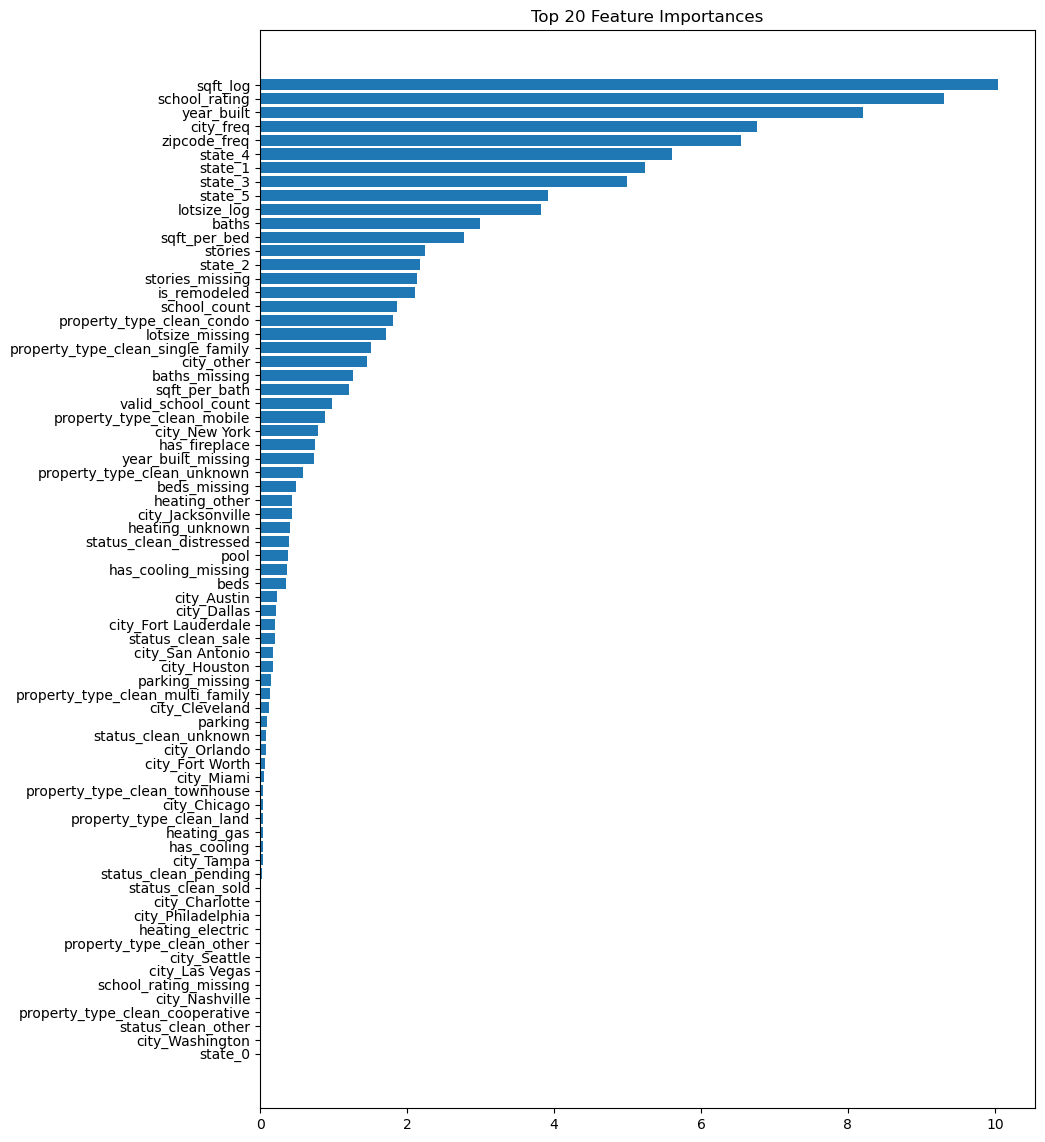

In [125]:
# Визуализируем
# Visualize
plt.figure(figsize=(10,14))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances')
plt.show()

Анализ важности признаков показал, что наибольшее влияние на стоимость недвижимости оказывают:

 - площадь объекта (sqft_log),
 - рейтинг школ (school_rating),
 - год строительства (year_built),
 - характеристики местоположения (city_freq, zipcode).

При этом было выявлено, что локационные признаки оказывают сопоставимое влияние с физическими характеристиками объекта.

Дополнительно значимыми оказались сконструированные признаки, такие как zipcode_freq и sqft_per_bed, что подтверждает эффективность этапа feature engineering.

Модель подтверждает, что стоимость недвижимости определяется не только характеристиками объекта, но и его окружением, включая район и качество инфраструктуры.

Feature importance analysis revealed that the following factors have the greatest impact on real estate value:

- property area (sqft_log),
- school rating (school_rating),
- year of construction (year_built),
- location characteristics (city_freq, zip code).

Moreover, it was found that location features have a comparable impact to the physical characteristics of the property.

Additionally, engineered features such as zipcode_freq and sqft_per_bed proved to be significant, confirming the effectiveness of the feature engineering stage.

The model confirms that the value of real estate is determined not only by the characteristics of the property, but also by its surroundings, including the area and the quality of infrastructure.

#### Вывод о качестве модели:

Несмотря на проведённую оптимизацию модели и признаков, средняя ошибка предсказания остаётся на уровне ~20%. Это обусловлено высокой вариативностью стоимости недвижимости и наличием факторов, не представленных в данных.
Анализ ошибок показал наличие эффекта регрессии к среднему, при котором модель переоценивает дешёвые объекты и недооценивает дорогие.
Таким образом, достигнутое качество является близким к верхней границе для данного набора признаков и используемых методов.
Дальнейшее улучшение модели возможно преимущественно за счёт расширения признакового пространства (например, добавления географических или текстовых признаков), а не за счёт изменения алгоритма.

#### Conclusion about the quality of the model:

Despite optimization of the model and features, the average prediction error remains at ~20%. This is due to the high variability of real estate prices and the presence of factors not represented in the data.
Error analysis revealed a regression-to-the-mean effect, whereby the model overvalues ​​cheaper properties and undervalues ​​more expensive ones.
Thus, the achieved quality is close to the upper bound for the given set of features and methods used.
Further improvement of the model is possible primarily by expanding the feature space (for example, adding geographic or text features), rather than by modifying the algorithm.

### 7. Разработка прототипа веб-сервиса
### 7. Developing a web service prototype

Для разработки прототипа веб-сервиса нужно сделать подготовку артефактов модели. Для этого:

 - создадим функцию preprocess_data()
 - сохраним preprocessing-артефакты:
   - bin_encoder.pkl
   - top_cities.pkl
   - city_freq.pkl
   - zipcode_freq.pkl
   - и медианы
- сохраняем признаки модели:
   - feature_names.pkl
- сериализуем обученную модель:
   - catboost_real_estate.pkl

To develop a web service prototype, we need to prepare model artifacts. To do this:

 - Create the preprocess_data() function
 - Save the preprocessing artifacts:
   - bin_encoder.pkl
   - top_cities.pkl
   - city_freq.pkl
   - zipcode_freq.pkl
   - and medians
 - Save the model features:
   - feature_names.pkl
 - Serialize the trained model:
   - catboost_real_estate.pkl

In [240]:
# Сохраняем медианы
# Save medians
sqft_median = data['sqft'].median()
baths_median = data['baths'].median()
beds_median = data['beds'].median()
stories_median = data['stories'].median()
school_rating_median = data['school_rating'].median()
year_built_median = data['year_built'].median()
lotsize_median = data['lotsize'].median()
parking_median = data['parking'].median()

In [241]:
# Binary Encoder
bin_encoder = ce.BinaryEncoder(cols=['state'])
bin_encoder.fit(data[['state']])

# top cities
top_cities = data['city'].value_counts().head(20).index.tolist()

# city frequency
city_freq = data['city'].value_counts(normalize=True).to_dict()

# zipcode frequency
zipcode_freq = data['zipcode'].value_counts(normalize=True).to_dict()

In [244]:
# Создадим функцию preprocessing со всеми преобразованиями, которые были сделаны с данными
# Create a preprocessing function with all the transformations that were done to the data
def preprocess_data(df):
    df = df.copy()
    df = df.drop_duplicates()
    df = df.drop(['mls-id', 'MlsId'], axis=1)
    df['pool'] = ((df['private pool'].notna()) | (df['PrivatePool'].notna())).astype(int)
    df = df.drop(columns=['private pool', 'PrivatePool'])
    df['propertyType'] = df['propertyType'].str.lower()
    df['propertyType'] = df['propertyType'].fillna('unknown')
    category_property = {'single_family':'single|detached',
                     'condo':'condo',
                     'cooperative':'coop|cooperative',
                     'townhouse':'townhome|townhouse',
                     'multi_family':'multi',
                     'mobile':'mobile|manufactured|modular',
                     'land':'land|lot|farm'
                    }
    df['property_type_clean'] = 'other'
    for category, pattern in category_property.items():
        df.loc[df['propertyType'].str.contains(pattern, na=False),'property_type_clean'] = category
    df.loc[df['propertyType'].isna() | (df['propertyType'] == 'unknown'), 'property_type_clean'] = 'unknown'
    df = df.drop(['propertyType'], axis=1)
    df['sqft'] = df['sqft'].str.replace(',', '', regex=False).str.extract(r'(\d+)', expand=False).astype(float)
    df['sqft'] = df['sqft'].replace(0, np.nan)
    df['sqft'] = df.groupby(['property_type_clean', 'state'])['sqft'].transform(lambda x: x.fillna(x.median()))
    df = df.drop(['street'], axis=1)
    df['target'] = df['target'].str.replace(',', '', regex=False).str.replace('$', '', regex=False)\
    .str.extract(r'(\d+)', expand=False).astype(float)
    df = df.dropna(subset=['target'])
    df['baths'] = df['baths'].str.replace(',', '', regex=False).str.extract(r'(\d+\.?\d*)', expand=False).astype(float)
    df.loc[df['baths'] > 15, 'baths'] = np.nan
    df['baths_missing'] = df['baths'].isna().astype(int)
    df['baths'] = df.groupby('property_type_clean')['baths'].transform(lambda x: x.fillna(x.median()))
    df = df[df['baths'] > 0].reset_index(drop=True)
    mask = df['beds'].str.contains('sqft|acre', case=False, na=False)
    df.loc[mask, 'beds'] = np.nan
    df['beds'] = df['beds'].str.replace(',', '', regex=False).str.extract(r'(\d+\.?\d*)', expand=False).astype(float)
    df.loc[df['beds'] > 20, 'beds'] = np.nan
    df.loc[df['beds'] == 0, 'beds'] = np.nan
    df['beds_missing'] = df['beds'].isna().astype(int)
    df['beds'] = df.groupby('property_type_clean')['beds'].transform(lambda x: x.fillna(x.median()))
    df = df[~df['status'].str.contains('rent', case=False, na=False)].reset_index(drop=True)
    category_status = {  'pending':'pending|contract|contingent|option',
                     'sold':'sold|closed',
                     'distressed':'foreclosure|auction',
                     'sale':'sale|active|new|price change|back on market|show|listing extended'
                  }
    df['status'] = df['status'].str.lower()
    df['status_clean'] = 'other'
    for category, pattern in category_status.items():
        df.loc[df['status'].str.contains(pattern, na=False), 'status_clean'] = category
    df.loc[df['status'].isna(),'status_clean'] = 'unknown'
    df = df.drop(['status'], axis=1)
    df['fireplace'] = df['fireplace'].str.lower()
    df['has_fireplace'] = 0
    df.loc[df['fireplace'].str.contains('yes|[1-9]|fireplace|gas|wood|room|familyrm|rm', na=False),'has_fireplace'] = 1
    df = df.drop(['fireplace'], axis=1)
    df = df.dropna(subset=['city']).reset_index(drop=True)
    df['stories'] = df['stories'].str.lower()
    df['stories'] = df['stories'].str.replace('one', '1', regex=False)
    df['stories'] = df['stories'].str.replace('two', '2', regex=False)
    df['stories'] = df['stories'].str.replace('three', '3', regex=False)
    df['stories'] = df['stories'].str.extract(r'(\d+\.?\d*)', expand=False).astype(float)
    df.loc[df['stories'] == 0, 'stories'] = np.nan
    df.loc[df['stories'] > 10, 'stories'] = np.nan
    df['stories_missing'] = df['stories'].isna().astype(int)
    df['stories'] = df.groupby(['property_type_clean', 'state'])['stories'].transform(lambda x: x.fillna(x.median()))
    df['stories'] = df['stories'].fillna(df['stories'].median())
    df = df[df['sqft'] >= 100]
    
    def outliers_iqr(data, feature):
        x = data[feature]
        quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75)
        iqr = quartile_3 - quartile_1
        lower_bound = quartile_1 - (iqr * 1.5)
        upper_bound = quartile_3 + (iqr * 1.5)
        outliers = data[(x < lower_bound) | (x > upper_bound)]
        cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
        return outliers, cleaned
    outliers, cleaned = outliers_iqr(df, 'sqft')
    df = cleaned.reset_index(drop=True)
    df = df[df['target'] > 30000.0].reset_index(drop=True)
    df = df[df['target'] < df['target'].quantile(0.99)]
    
    def process_schools(schools):
        try:
            tree = ast.literal_eval(schools)
        except:
            return np.nan, np.nan, np.nan
        try:
            school_count = len(tree[0]['name'])
        except:
            return np.nan, np.nan, np.nan
        try:
            rating = tree[0]['rating']
        except:
            return np.nan, np.nan, np.nan
        clean_rating = []
        for x in rating:
            try:
                clean_rating.append(float(x.split('/')[0]))
            except:
                continue
        valid_school_count = len(clean_rating)
        if len(clean_rating) == 0:
            average_rating = np.nan
        else:
            average_rating = sum(clean_rating) / len(clean_rating)
        return average_rating, school_count, valid_school_count
    df[['school_rating', 'school_count', 'valid_school_count']] = (df['schools'].apply(process_schools).apply(pd.Series))
    df['school_rating_missing'] = df['school_rating'].isna().astype(int)
    df['school_rating'] = df.groupby(['property_type_clean', 'state'])['school_rating'].transform(lambda x: x.fillna(x.median()))
    df = df.dropna(subset=['school_rating']).reset_index(drop=True)
    df = df.drop(['schools'], axis=1)
    
    def process_home_facts(home_facts):
        try:
            tree = ast.literal_eval(home_facts)
        except:
            return np.nan, np.nan
        facts_dict = {item['factLabel']: item['factValue'] for item in tree['atAGlanceFacts']}
        value = facts_dict.get('Year built')
        match = None
        if value is None or value == '' or value == '—':
            year_built = np.nan
        else:
            value = str(value).strip()
            match = re.search(r'\d{4}', value)
        if match:
            year_built = int(match.group())
        else:
            year_built = np.nan            
        if year_built < 1600 or year_built > 2025:
            year_built = np.nan
        value_2 = facts_dict.get('Remodeled year')
        match_2 = None
        if value_2 is None or value_2 == '' or value_2 == '—':
            remodeled_year = np.nan
        else:
            value_2 = str(value_2).strip()
            match_2 = re.search(r'\d{4}', value_2)  
            if match_2:
                remodeled_year = int(match_2.group())
            else:
                remodeled_year = np.nan    
        if remodeled_year < 1600 or remodeled_year > 2026:
            remodeled_year = np.nan 
        if not np.isnan(year_built) and not np.isnan(remodeled_year):
            if remodeled_year < year_built or remodeled_year > 2026:
                remodeled_year = np.nan       
        return year_built, remodeled_year
    df[['year_built', 'remodeled_year']] = df['homeFacts'].apply(process_home_facts).apply(pd.Series)
    df['year_built_missing'] = df['year_built'].isna().astype(int)
    df['year_built'] = df['year_built'].fillna(df['year_built'].median())
    df['is_remodeled'] = df['remodeled_year'].notna().astype(int)
    df = df.drop(['remodeled_year'], axis=1)
    def process_home_facts_2(home_facts):
        try:
            tree = ast.literal_eval(home_facts)
        except:
            return np.nan
        facts_dict = {item['factLabel']: item['factValue'] for item in tree['atAGlanceFacts']}
        value = facts_dict.get('lotsize')
        match = None
        if value is None or value == '' or value == '—':
            lotsize = np.nan
        else:
            value = str(value).lower().replace(',', '').strip()
            if 'acre' in value:
                match = re.search(r'\d+\.?\d*', value)
                lotsize = float(match.group()) * 43560 if match else np.nan
            else:
                match = re.search(r'\d+', value)
                lotsize = float(match.group()) if match else np.nan                
        return lotsize
    df['lotsize'] = df['homeFacts'].apply(process_home_facts_2)
    df.loc[df['lotsize'] > 1e6, 'lotsize'] = np.nan
    df.loc[df['lotsize'] == 0, 'lotsize'] = np.nan
    df['lotsize_missing'] = df['lotsize'].isna().astype(int)
    df['lotsize'] = df.groupby(['property_type_clean', 'state'])['lotsize'].transform(lambda x: x.fillna(x.median()))
    df['lotsize'] = df['lotsize'].fillna(df['lotsize'].median())
    def process_home_facts_3(home_facts):
        try:
            tree = ast.literal_eval(home_facts)
        except:
            return np.nan
        facts_dict = {item['factLabel']: item['factValue'] for item in tree['atAGlanceFacts']}
        value = facts_dict.get('Heating')
        if value is None or value == '' or value == '—':
            heating = np.nan
        else:
            value = str(value).lower().strip()
            if 'electric' in value:
                heating = 'electric'
            elif 'gas' in value:
                heating = 'gas'
            else:
                heating = 'other'
        value_2 = facts_dict.get('Cooling') 
        if value_2 is None or value_2 == '' or value_2 == '—':
            has_cooling = np.nan
        else:
            value_2 = str(value_2).lower()      
            if 'no' in value_2:
                has_cooling = 0
            elif 'cool' in value_2 or 'air' in value_2:
                has_cooling = 1
            else:
                has_cooling = np.nan
        value_3 = facts_dict.get('Parking')  
        match = None
        if value_3 is None or value_3 == '' or value_3 == '—':
            parking = np.nan
        else:
            value_3 = str(value_3).lower()
            match = re.search(r'\d+', value_3) 
            if match:
                val = float(match.group())
                if val > 20: 
                    parking = np.nan
                else:
                    parking = val
            else:
                parking = np.nan
        return heating, has_cooling, parking
    df[['heating', 'has_cooling', 'parking']] = df['homeFacts'].apply(process_home_facts_3).apply(pd.Series)
    df['parking_missing'] = df['parking'].isna().astype(int)
    df['parking'] = df['parking'].fillna(df['parking'].median())
    df['has_cooling_missing'] = df['has_cooling'].isna().astype(int)
    df['has_cooling'] = df['has_cooling'].fillna(0)
    df['heating'] = df['heating'].fillna('unknown')
    df = df.drop(['homeFacts'], axis=1)
    df['sqft_per_bed'] = df['sqft'] / df['beds']
    df['sqft_per_bath'] = df['sqft'] / df['baths']
    df['sqft_log'] = np.log1p(df['sqft'])
    df['lotsize_log'] = np.log1p(df['lotsize'])
    df = df.drop(['sqft', 'lotsize'], axis=1)
    type_bin = bin_encoder.transform(df[['state']])
    df = pd.concat([df, type_bin], axis=1)
    df = df.drop(['state'], axis=1)
    df = pd.get_dummies(df, columns=['property_type_clean', 'status_clean', 'heating'])
    df['city_freq'] = df['city'].map(city_freq)
    df['city'] = df['city'].str.strip()
    df.loc[df['city'].isin(['New York', 'Brooklyn']), 'city'] = 'New York'
    df['city'] = df['city'].where(df['city'].isin(top_cities), 'other')
    df = pd.get_dummies(df, columns=['city'], drop_first=True)
    df['zipcode_freq'] = df['zipcode'].map(zipcode_freq)
    df = df.drop(['zipcode'], axis=1)
    df = df.reset_index(drop=True)
    bool_cols = df.select_dtypes(include='bool').columns
    df[bool_cols] = df[bool_cols].astype(int)

    return df

In [246]:
# Загружаем данные
# Loading data
data = pd.read_csv("data_property.csv")

# Обрабатываем сырые данные
# Processing raw data
data_encoded = preprocess_data(data)

In [243]:
X = data_encoded.drop(['target', 'target_log'], axis=1)
y = data_encoded['target_log']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

final_model = CatBoostRegressor(
    iterations=540,
    depth=16,
    learning_rate=0.16014,
    random_state=42,
    verbose=0
)

final_model.fit(X_train, y_train)

In [245]:
# Делаем сериализацию
# We do serialization
import joblib

joblib.dump(bin_encoder, 'bin_encoder.pkl')
joblib.dump(top_cities, 'top_cities.pkl')
joblib.dump(city_freq, 'city_freq.pkl')
joblib.dump(zipcode_freq, 'zipcode_freq.pkl')
joblib.dump(sqft_median, 'sqft_median.pkl')
joblib.dump(baths_median, 'baths_median.pkl')
joblib.dump(beds_median, 'beds_median.pkl')
joblib.dump(stories_median, 'stories_median.pkl')
joblib.dump(school_rating_median, 'school_rating_median.pkl')
joblib.dump(year_built_median, 'year_built_median.pkl')
joblib.dump(lotsize_median, 'lotsize_median.pkl')
joblib.dump(parking_median, 'parking_median.pkl')
joblib.dump(final_model, 'catboost_real_estate.pkl')
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')

['feature_names.pkl']

#### Реализация API

 - для создания веб-сервиса использован FastAPI
 - создан файл main.py
 - реализован endpoint /predict
 - API:
   - принимает сырые данные недвижимости в формате JSON
   - выполняет preprocessing
   - приводит признаки к обученному формату
   - делает предсказание стоимости недвижимости
   - возвращает результат в JSON

#### API Implementation

- FastAPI was used to create the web service
- main.py file was created
- /predict endpoint was implemented
- API:
   - Accepts raw real estate data in JSON format
   - Performs preprocessing
   - Converts features to a trained format
   - Makes a real estate price prediction
   - Returns the result in JSON

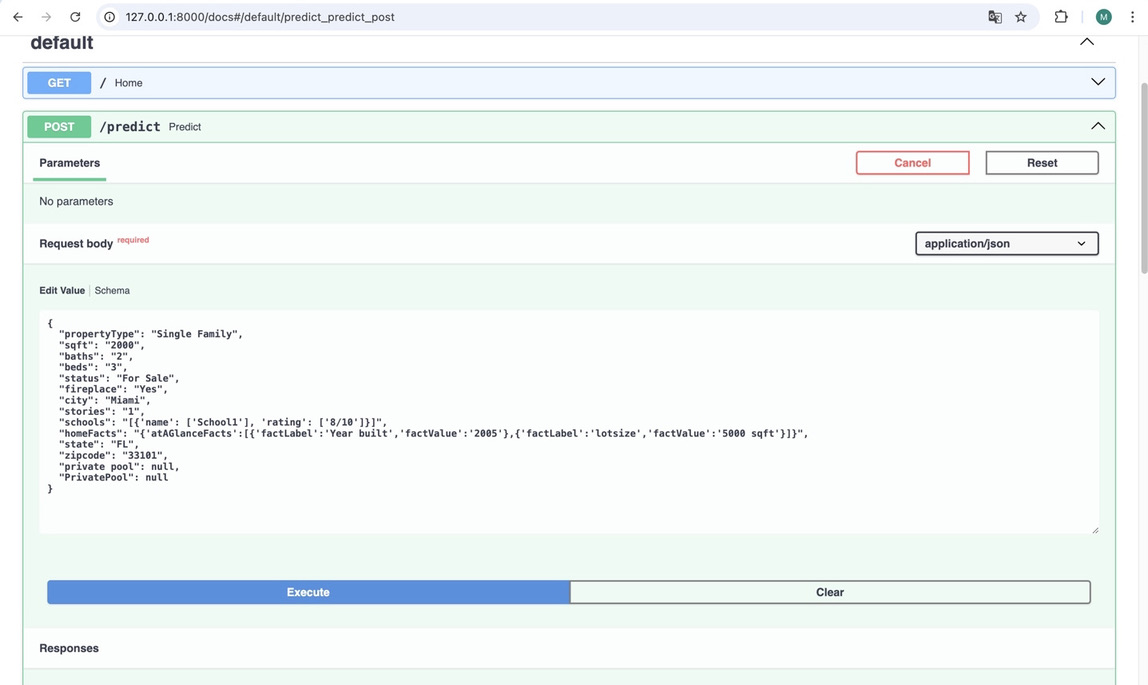

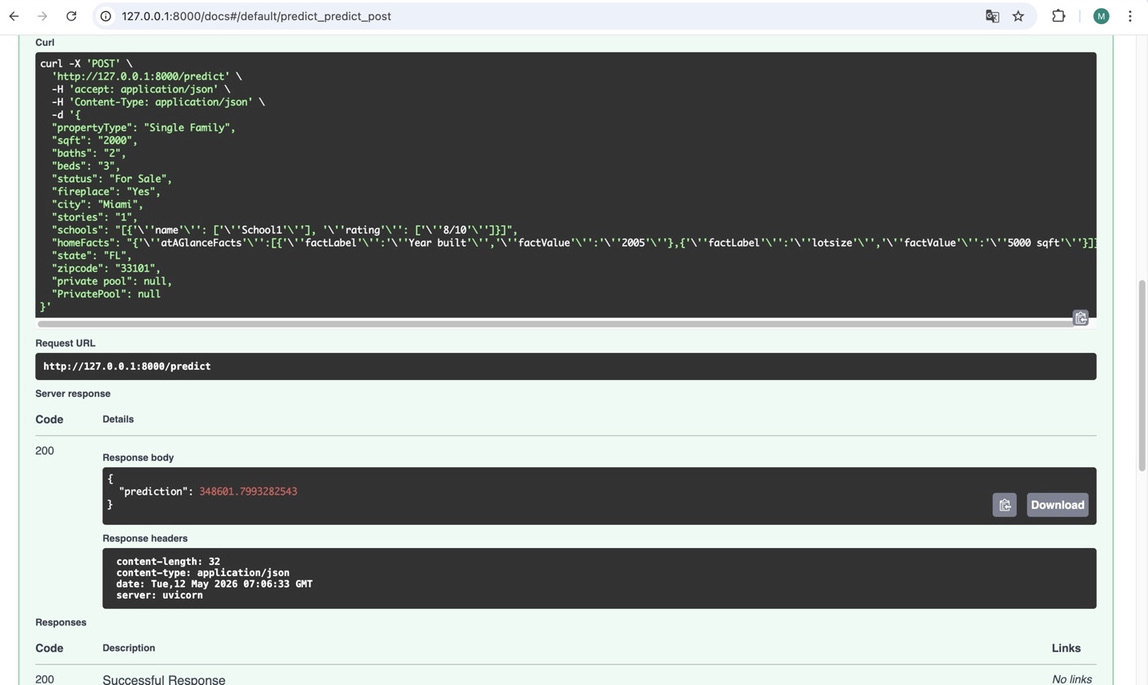

В ходе проекта была обучена модель прогнозирования стоимости недвижимости и реализован прототип веб-сервиса для получения предсказаний через API.

The project trained a real estate price forecasting model and implemented a prototype web service for receiving predictions via an API.